In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:

 (X_train,Y_train),(X_test,Y_test)=fashion_mnist.load_data()

In [ ]:
display(X_train.shape)
display(X_test.shape)
display(Y_train.shape)
display(Y_test.shape)

(60000, 28, 28)

(10000, 28, 28)

(60000,)

(10000,)

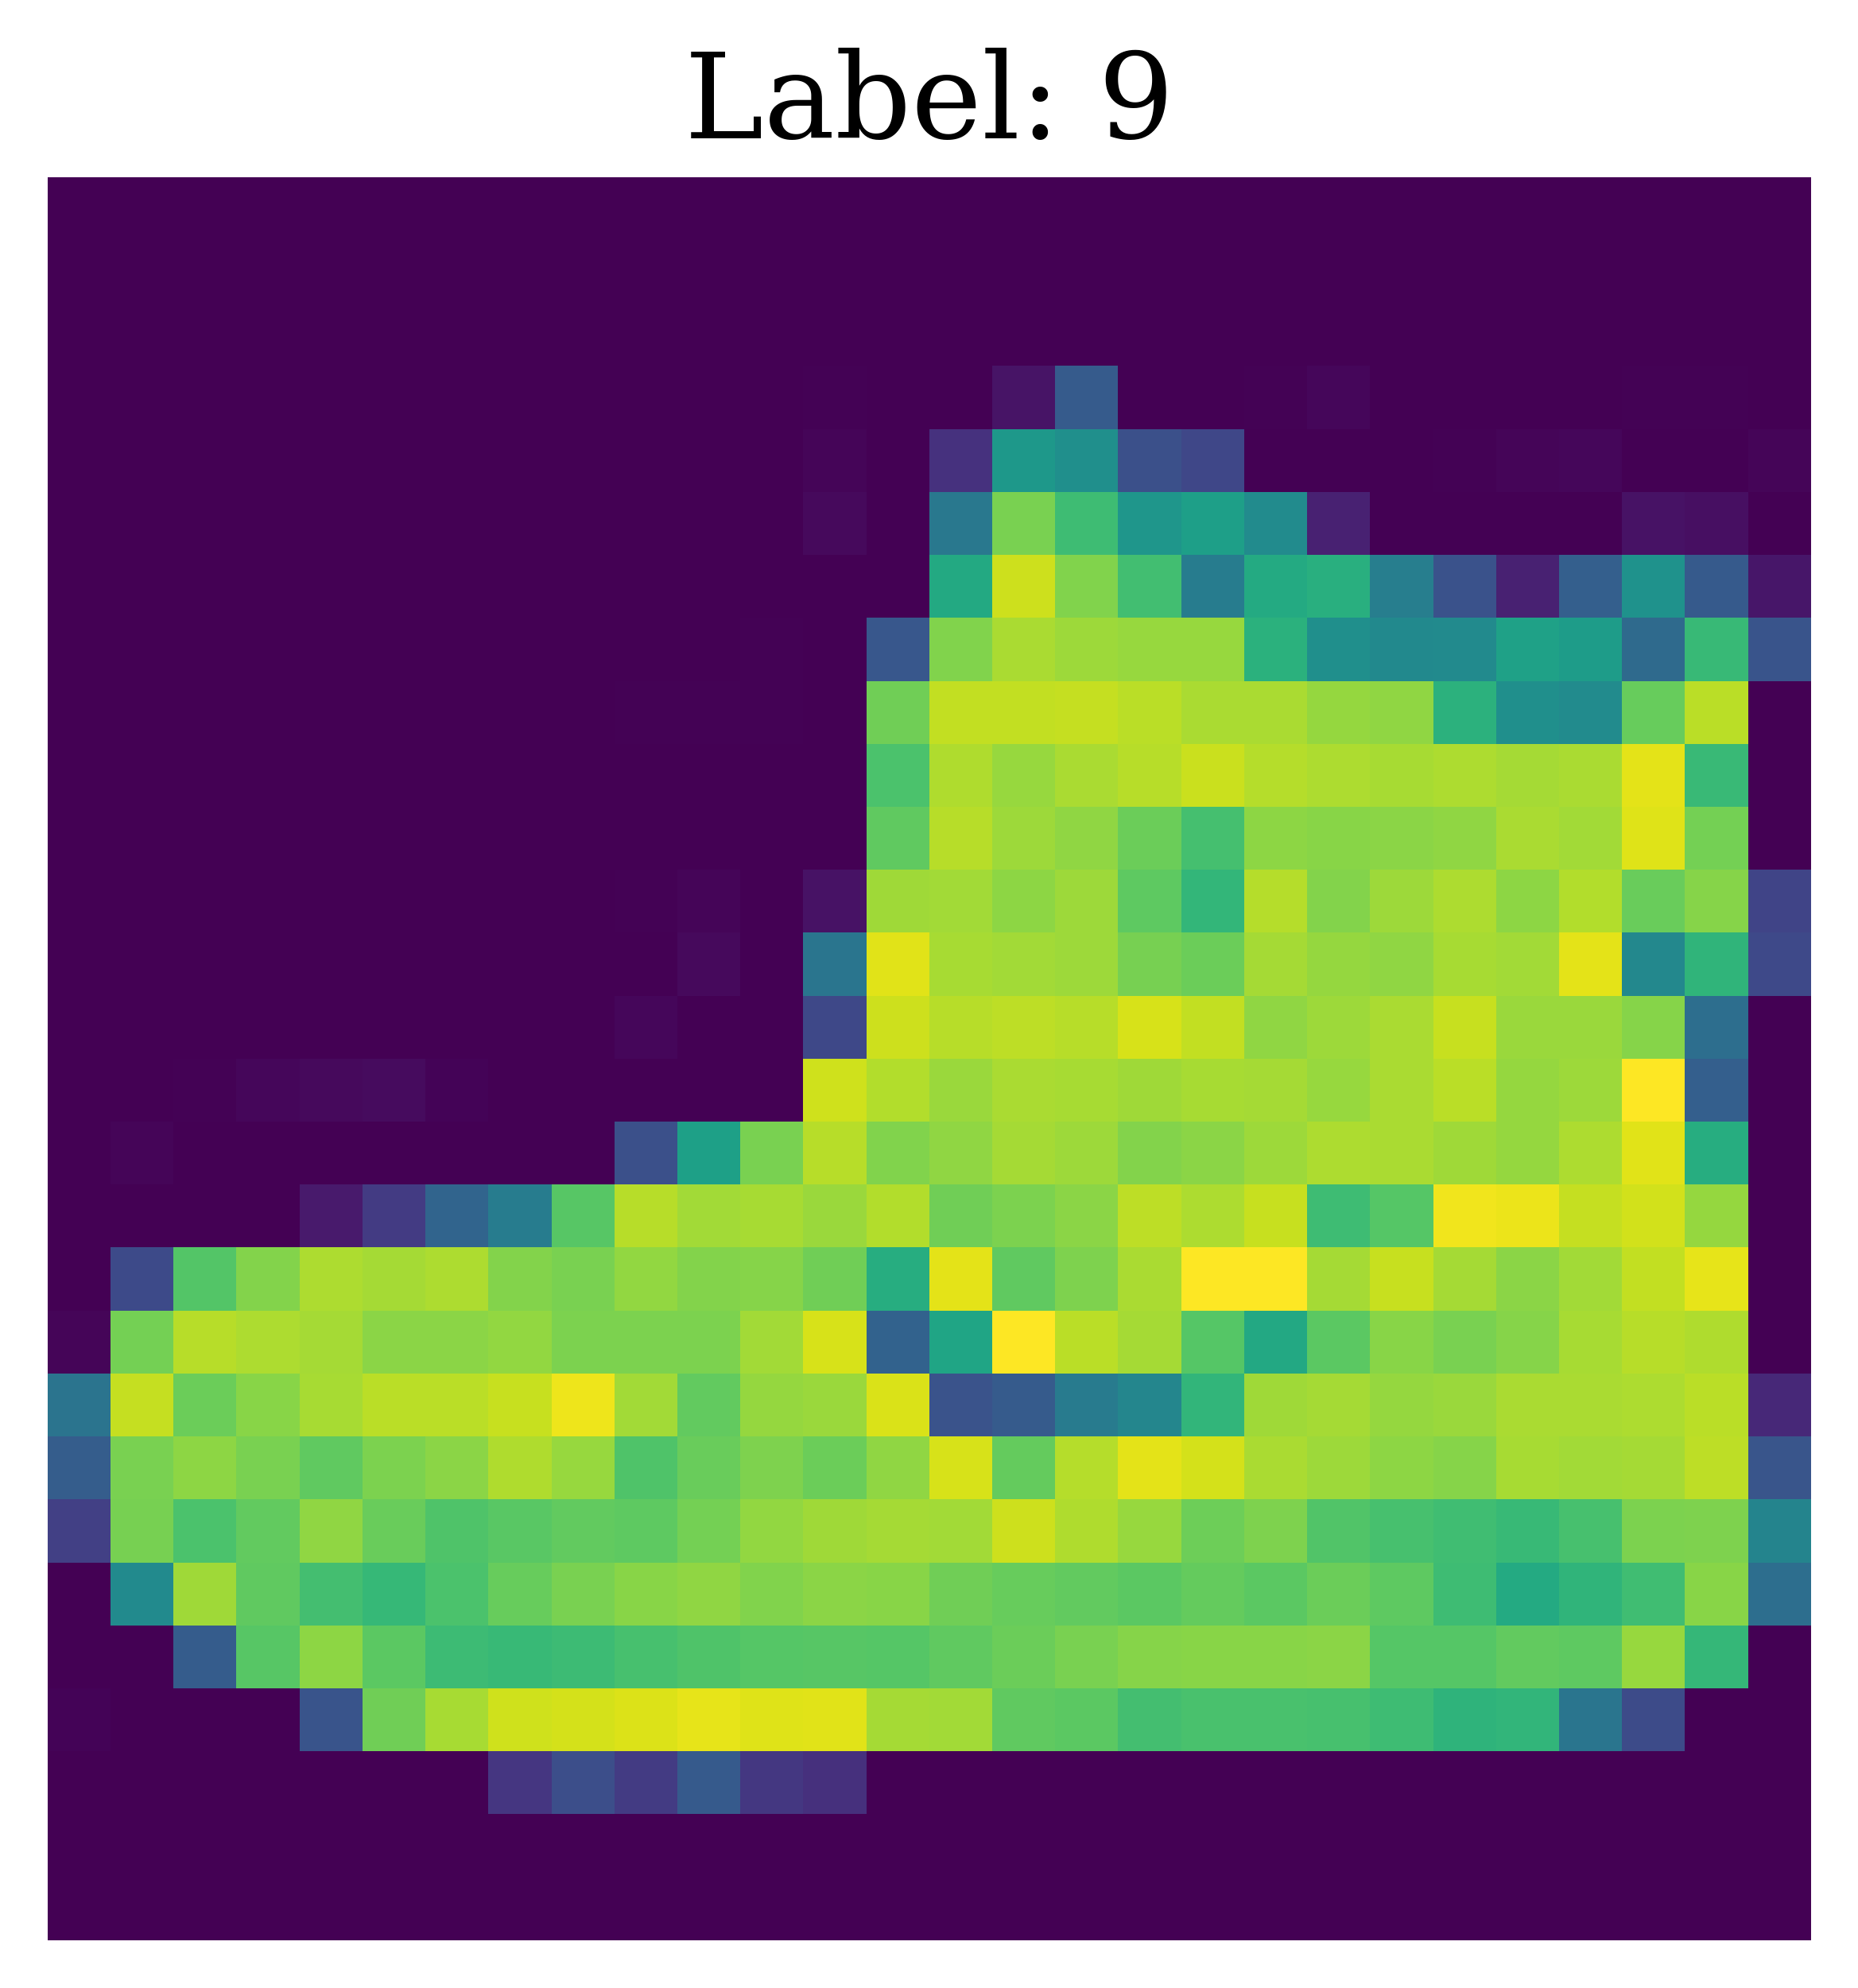

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(f"Label: {Y_train[0]}")
plt.axis('off')
plt.show()



In [ ]:
X_train_re=X_train.reshape(-1,784)
X_test_re=X_test.reshape(-1,784)

In [ ]:
display(X_train_re.shape)
display(X_test_re.shape)

(60000, 784)

(10000, 784)

In [ ]:
display(X_train.shape)

(60000, 28, 28)

In [ ]:
X_train_df=pd.DataFrame(X_train_re)
Y_train_df=pd.DataFrame(Y_train)
X_test_df=pd.DataFrame(X_test_re)
Y_test_df=pd.DataFrame(Y_test)
display(X_train_df)
display(X_test_df)
display(Y_train_df)
display(Y_test_df)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,66,54,50,5,0,1,0,0,0,0


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,2,3,0,3,174,189,67,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,164,58,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,21,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,2,0,1,1,0,0,0,...,71,12,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,31,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,27,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0
0,9
1,0
2,0
3,3
4,0
...,...
59995,5
59996,1
59997,3
59998,0


,0
0,9
1,2
2,1
3,1
4,6
...,...
9995,9
9996,1
9997,8
9998,1


In [ ]:
display(Y_train_df)


,0
0,9
1,0
2,0
3,3
4,0
...,...
59995,5
59996,1
59997,3
59998,0


In [ ]:
display(Y_train_df.value_counts())

,count
0,
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000


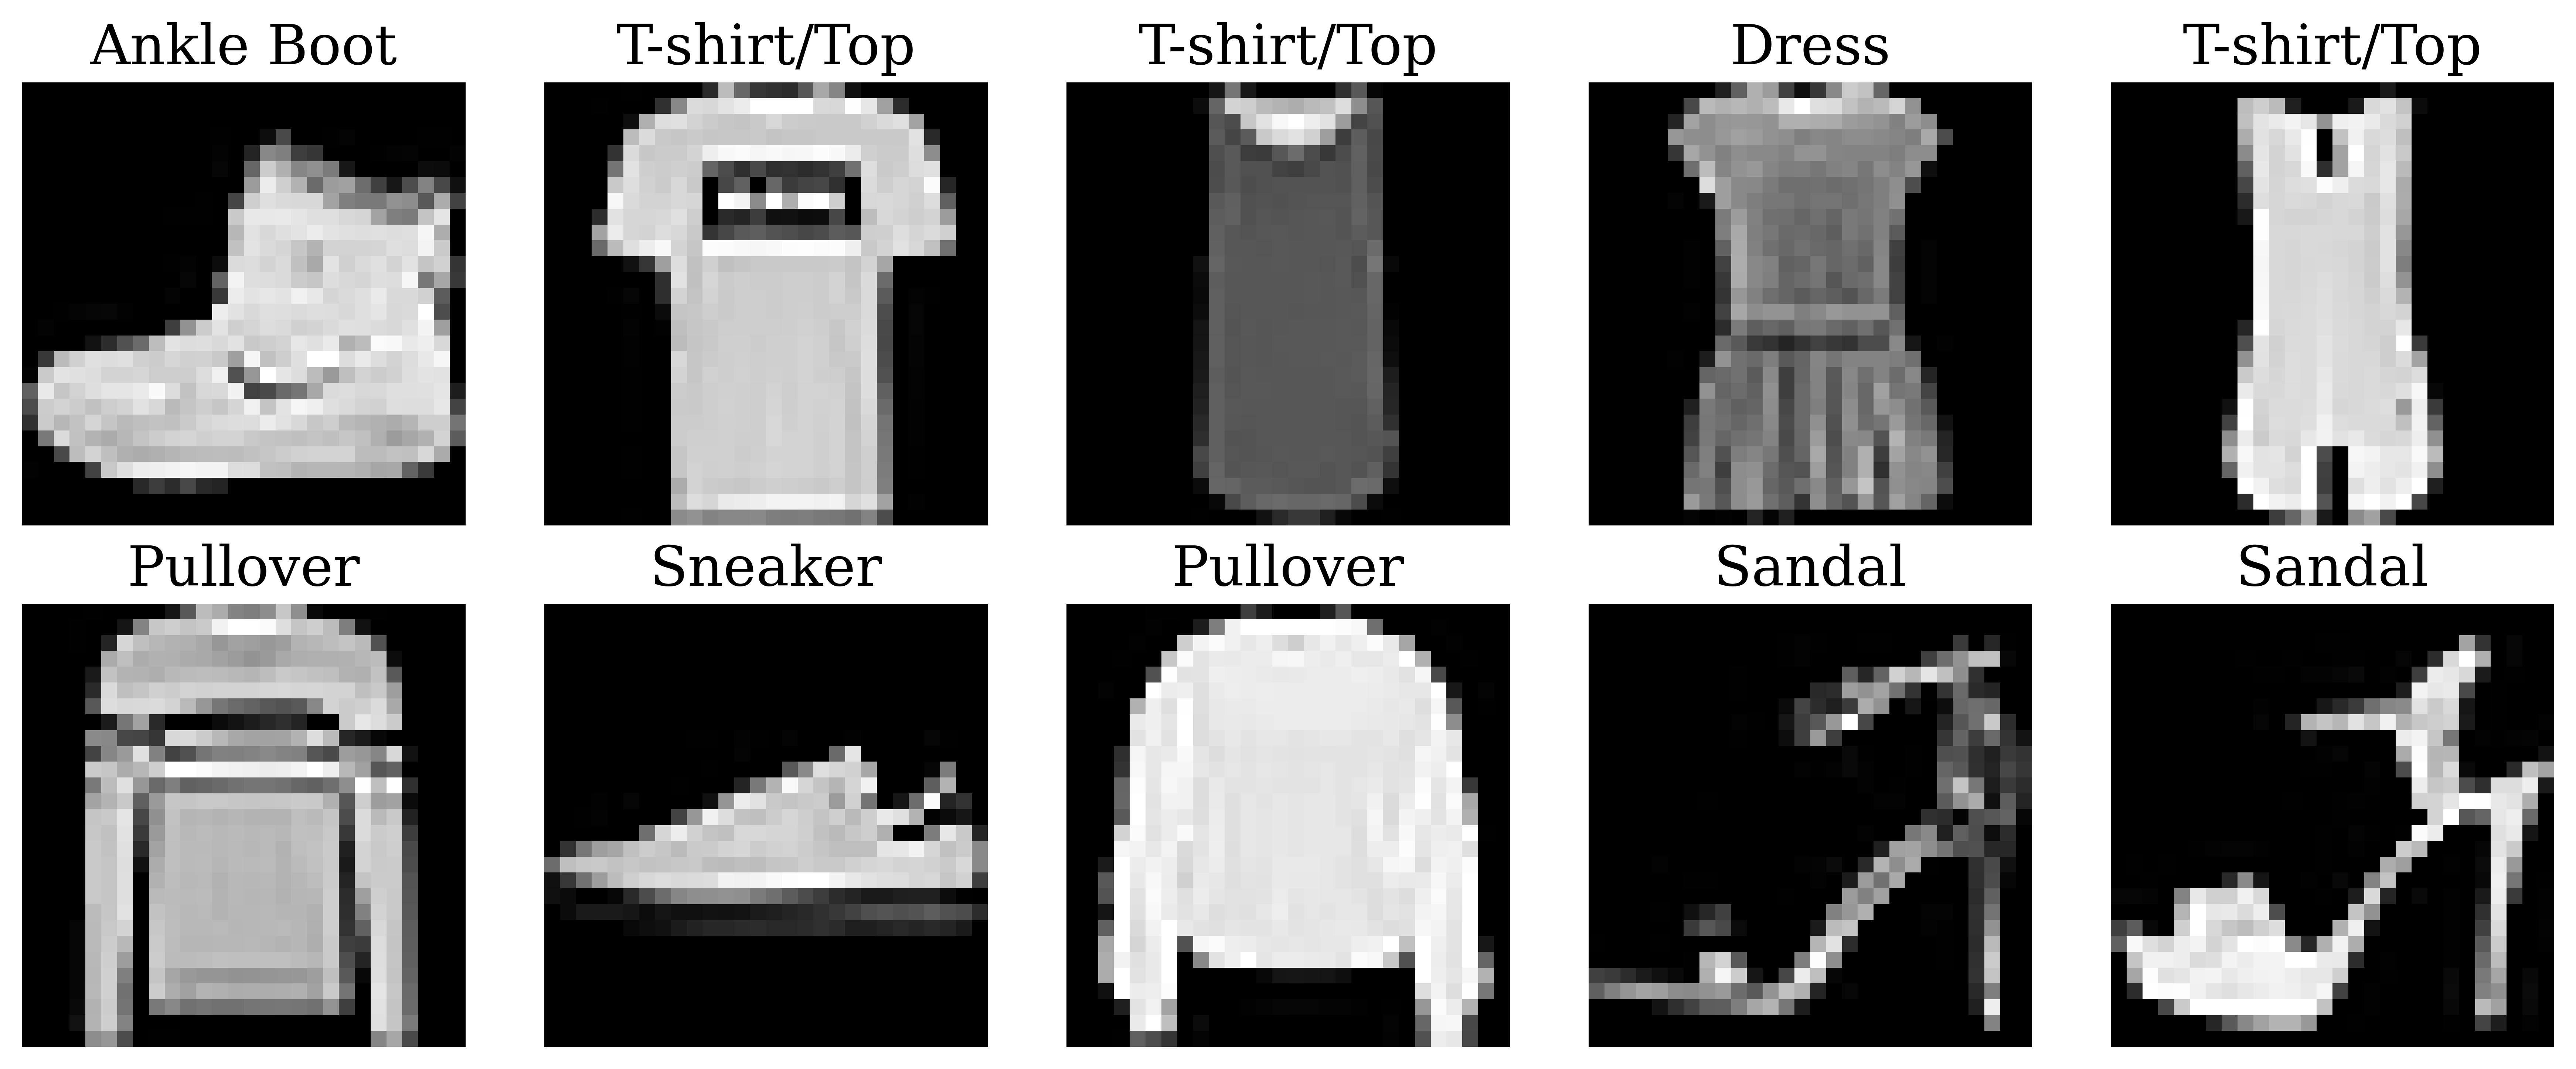

<Figure size 3840x2880 with 0 Axes>

In [ ]:
class_names = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat", "Sandal","Shirt", "Sneaker", "Bag", "Ankle Boot"
]
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[Y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.savefig(
    "Sample_images.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
X_train_re=X_train_re.astype("float32")/255.0
X_test_re=X_test_re.astype("float32")/255.0

In [ ]:
display(X_train_re)
display(X_test_re)
print("Minimum pixel value:", X_train_re.min())
print("Maximum pixel value:", X_train_re.max())

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:

display(X_train_df)
display(Y_train_df)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,66,54,50,5,0,1,0,0,0,0


,0
0,9
1,0
2,0
3,3
4,0
...,...
59995,5
59996,1
59997,3
59998,0


In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# ohe=OneHotEncoder(sparse_output=False)
# Y_train_df=Y_train_df.reshape(-1,1)
# Y_test_df=Y_test_df.reshape(-1,1)
# Y_train_df=ohe.fit_transform(Y_train_df)
# Y_test_df=ohe.transform(Y_test_df)

In [ ]:
from tensorflow.keras.utils import to_categorical
Y_train_cat=to_categorical(Y_train,num_classes=10)
Y_test_cat=to_categorical(Y_test,num_classes=10)


In [ ]:
display(Y_train)
display(Y_test)

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172,
        132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242,
        255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150,
        162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162,
        155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187,
        184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210,
        212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  88, 221, 215, 217, 219, 211, 185, 150, 118,
        107,  99,  88,  83,  90, 135, 212, 203, 207, 219, 169,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  27, 118, 162,  40,   0,   0,   0,  10,
         19,  28,  39,  47,  36,   0,   0, 203, 230, 220, 203,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 138, 136,  71,  69,  54, 216, 217, 203, 184,
        168, 163, 162, 163, 178, 221, 186,  38,  26,   7,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  67, 134, 154, 224, 129,  66,  81, 117, 129,
        128, 132, 137, 131, 129,  86,  73, 157, 151, 134, 216,  18,   0,
          0,   0],
       [  0,   0,   0,   0, 203, 198, 172, 183, 206, 255, 255, 250, 243,
        240, 239, 235, 238, 244, 255, 238, 184, 160,  86,  98,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 122, 188, 224, 151, 105, 127,  97, 100, 105,
        114, 117, 117, 113, 103,  98, 111, 142, 254, 191, 255,  49,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 179, 200,  95, 154, 198, 197, 200, 200,
        198, 197, 198, 199, 202, 200, 176,  86, 206, 157, 162,  10,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 201, 229,  71, 144, 194, 181, 183, 179,
        182, 180, 179, 180, 190, 185, 197,  76, 219, 185, 201,  34,   0,
          0,   0],
       [  0,   0,   0,   0, 199, 193, 226,  58, 154, 192, 184, 187, 184,
        186, 184, 185, 183, 192, 191, 200,  56, 219, 203, 207,  60,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 194, 224,  41, 163, 190, 186, 186, 184,
        185, 183, 185, 178, 190, 194, 202,  33, 211, 200, 206,  73,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 197, 222,  17, 172, 190, 186, 187, 182,
        186, 185, 187, 180, 187, 193, 202,  26, 212, 202, 203,  76,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 177, 189, 184, 185, 178,
        184, 183, 184, 180, 183, 189, 203,  35, 196, 203, 203,  84,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 185, 187, 185, 187, 180,
        184, 182, 183, 178, 182, 183, 205,  44, 159, 207, 201,  85,   0,
          0,   0],
       [  0,   0,   0,   0, 187, 198, 225,   0, 194, 188, 184, 185, 180,
        183, 183, 184, 181, 181, 177, 206,  46, 129, 211, 200,  88,   0,
          0,   0],
       [  0,   0,   0,   6, 186, 200, 211,   0, 199, 189, 184, 184, 185,
        182, 183, 184, 185, 182, 175, 205,  50,  97, 216, 197,  93,   0,
          0,   0],
       [  0,   0,   0,   5, 185, 204, 184,   0, 202, 188, 182, 182, 183,
        183, 184, 182, 180, 182, 174, 202,  63,  59, 220, 196,  94,   0,
          0,   0],
       [  0,   0,   0,   5, 184, 206, 157,   0, 204, 187, 187, 189, 192,
        190, 190, 191, 190, 187, 183, 202,  78,  35, 222, 197,  95,   0,
          0,   0],
       [  0,   0,   0,   5, 183, 208, 127,   0, 197, 166, 153, 149, 149,
        146, 148, 149, 150, 151, 158, 191,  90,   8, 223, 195,  99,   0,
          0,   0],
       [  0,   0,   0,   6, 184, 208, 11

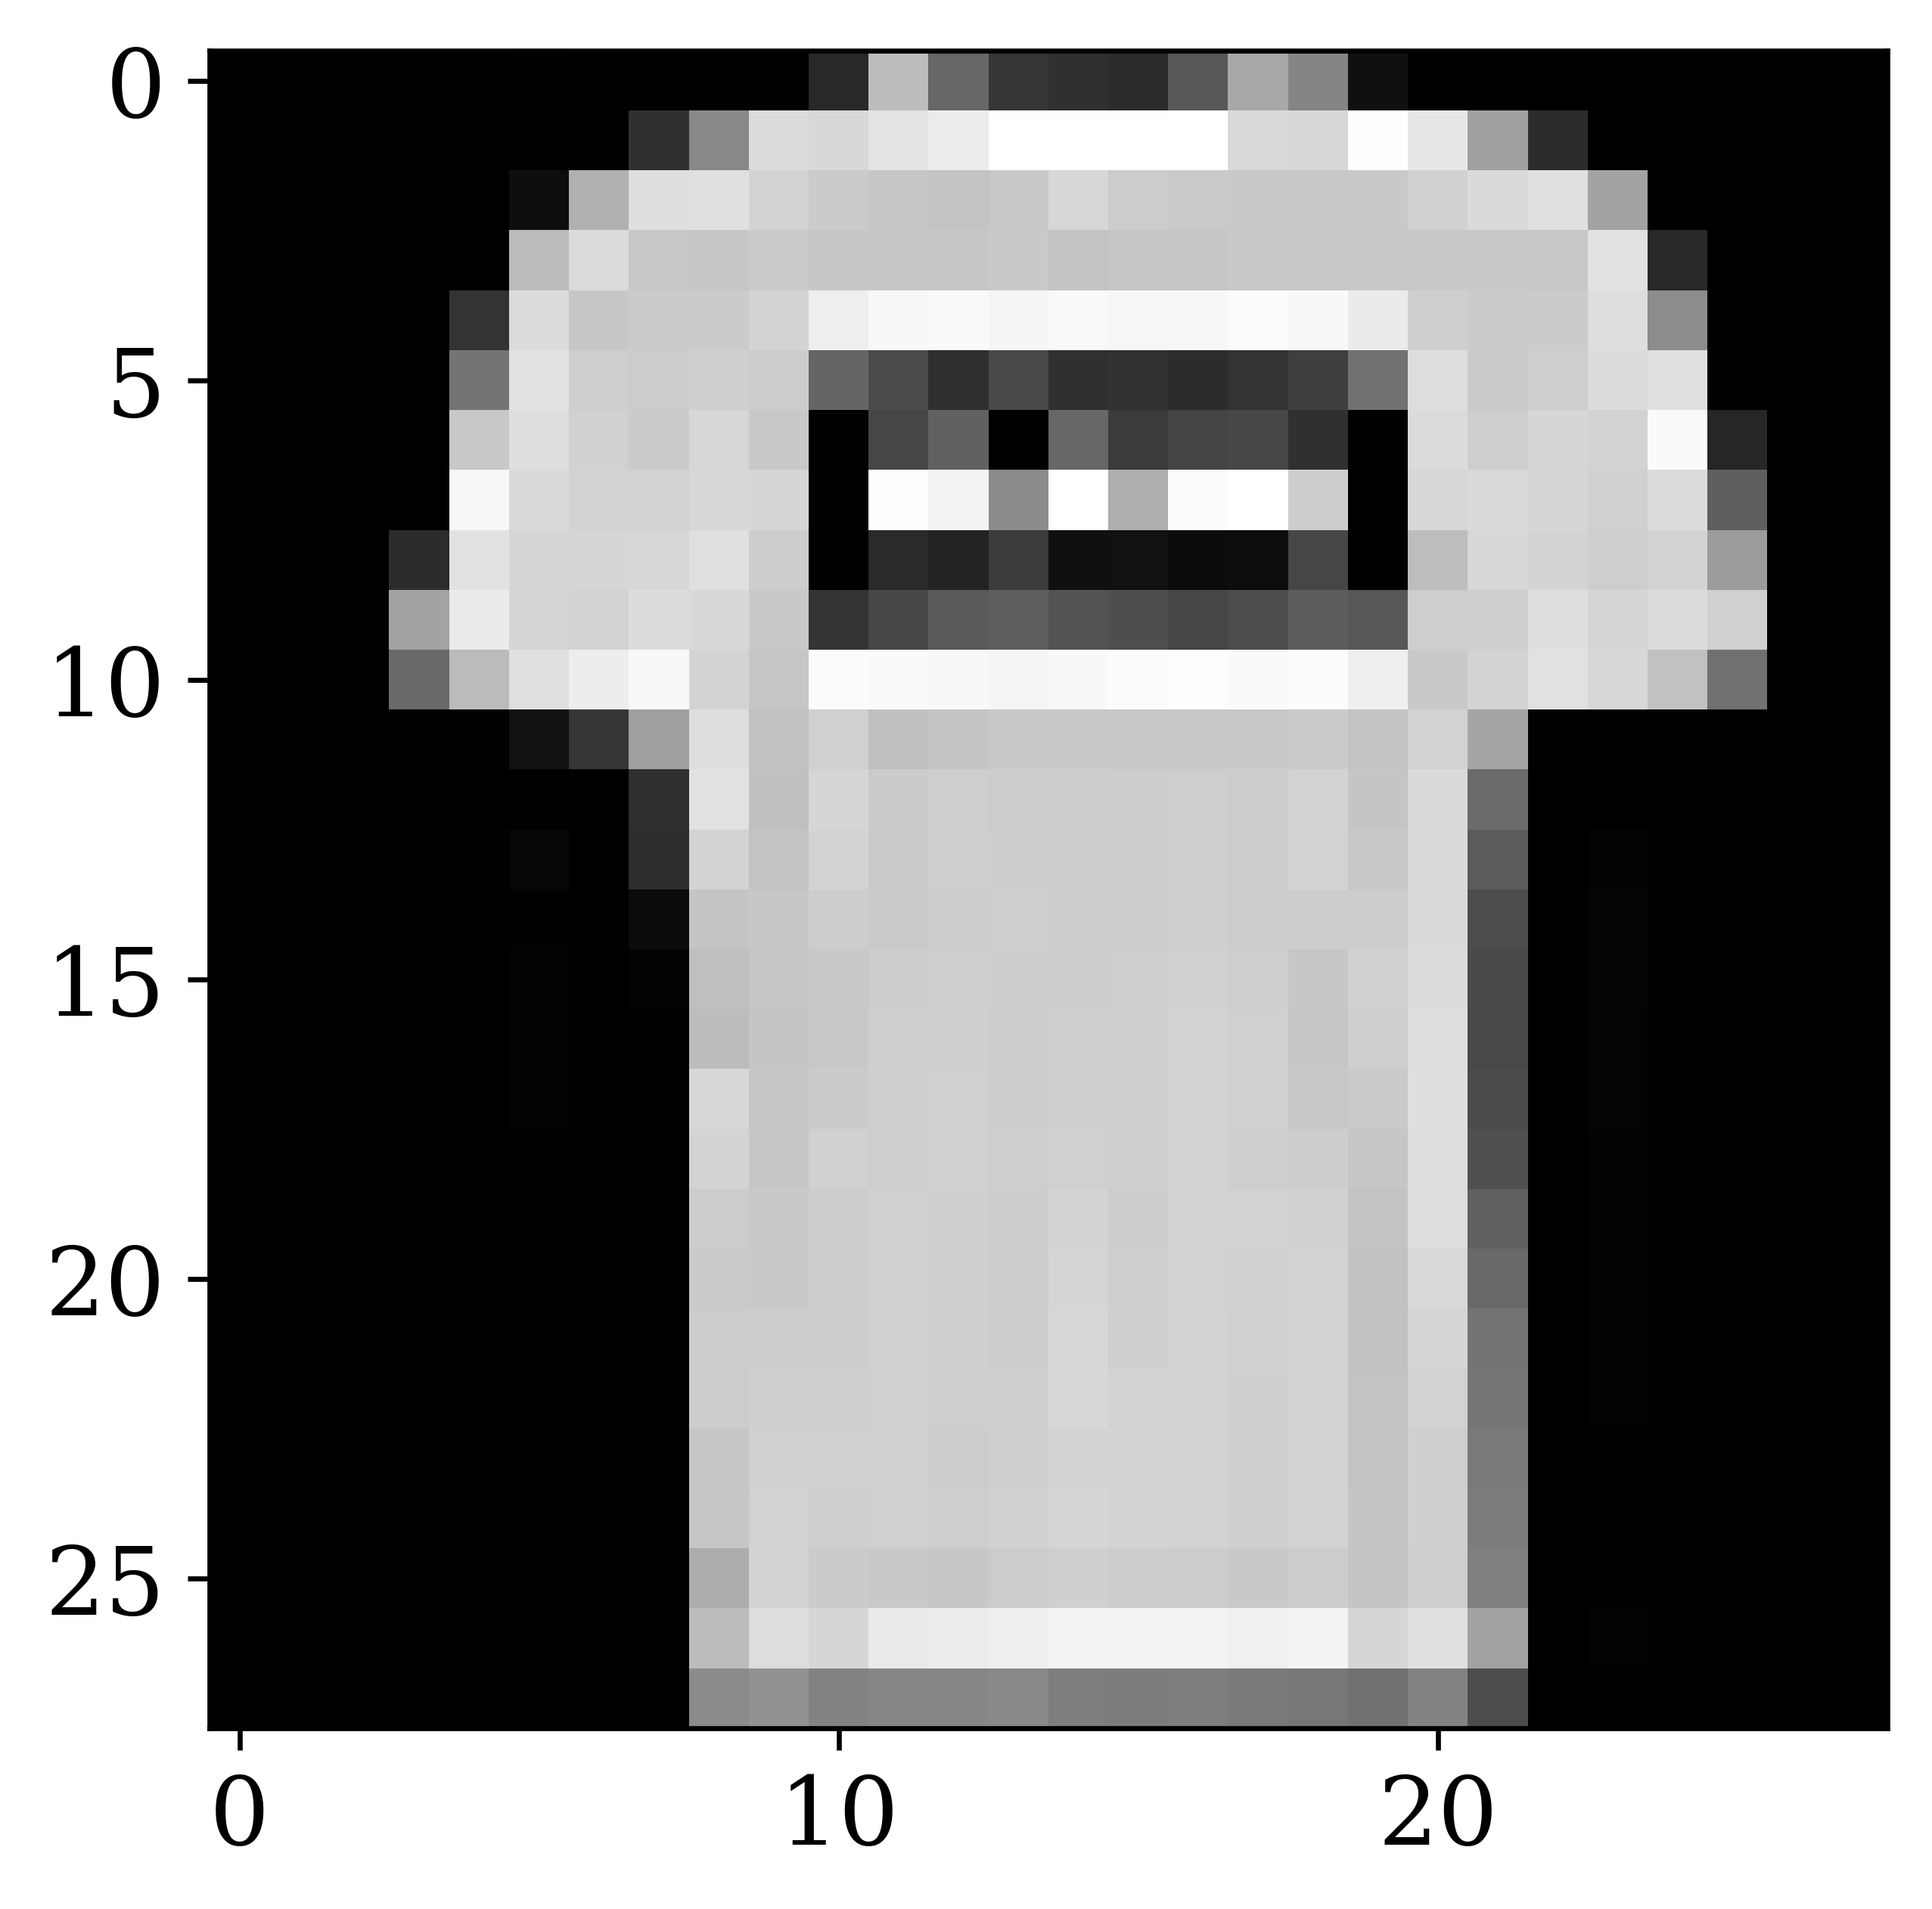

In [ ]:
display(X_train[5])
display(plt.imshow(X_train[1],cmap='gray'))

In [ ]:
display(Y_train.shape)

(60000,)

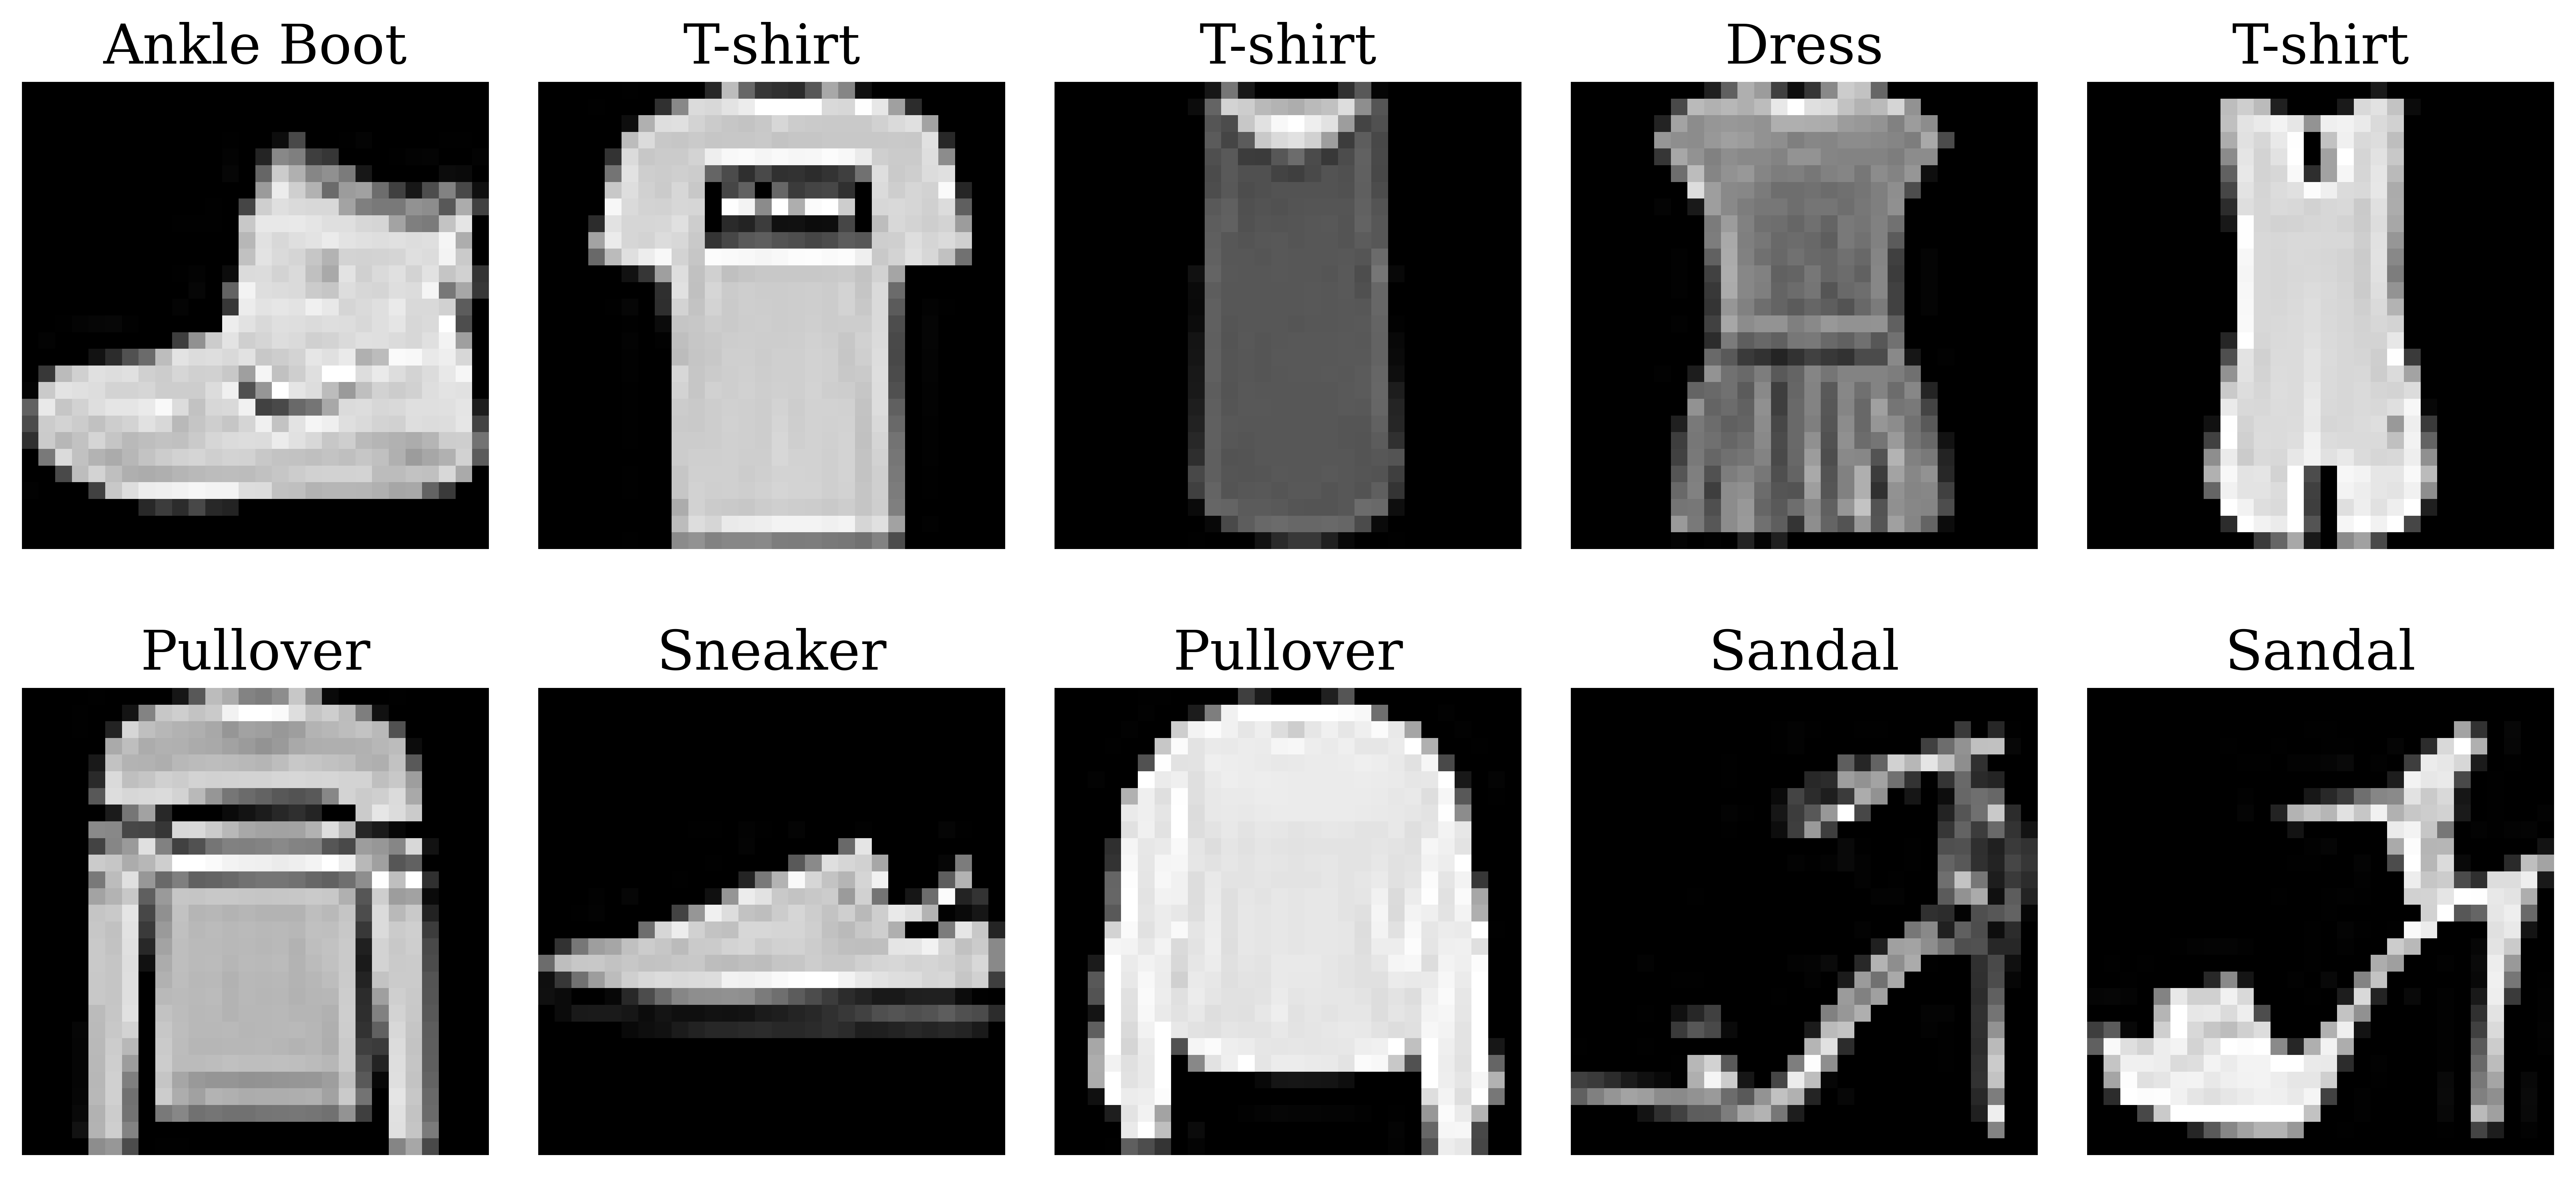

In [ ]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
plt.figure(figsize=(12,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i],cmap="gray")
  plt.title(class_names[Y_train[i]])
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
unique,counts=np.unique(Y_train,return_counts=True)
print(unique)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


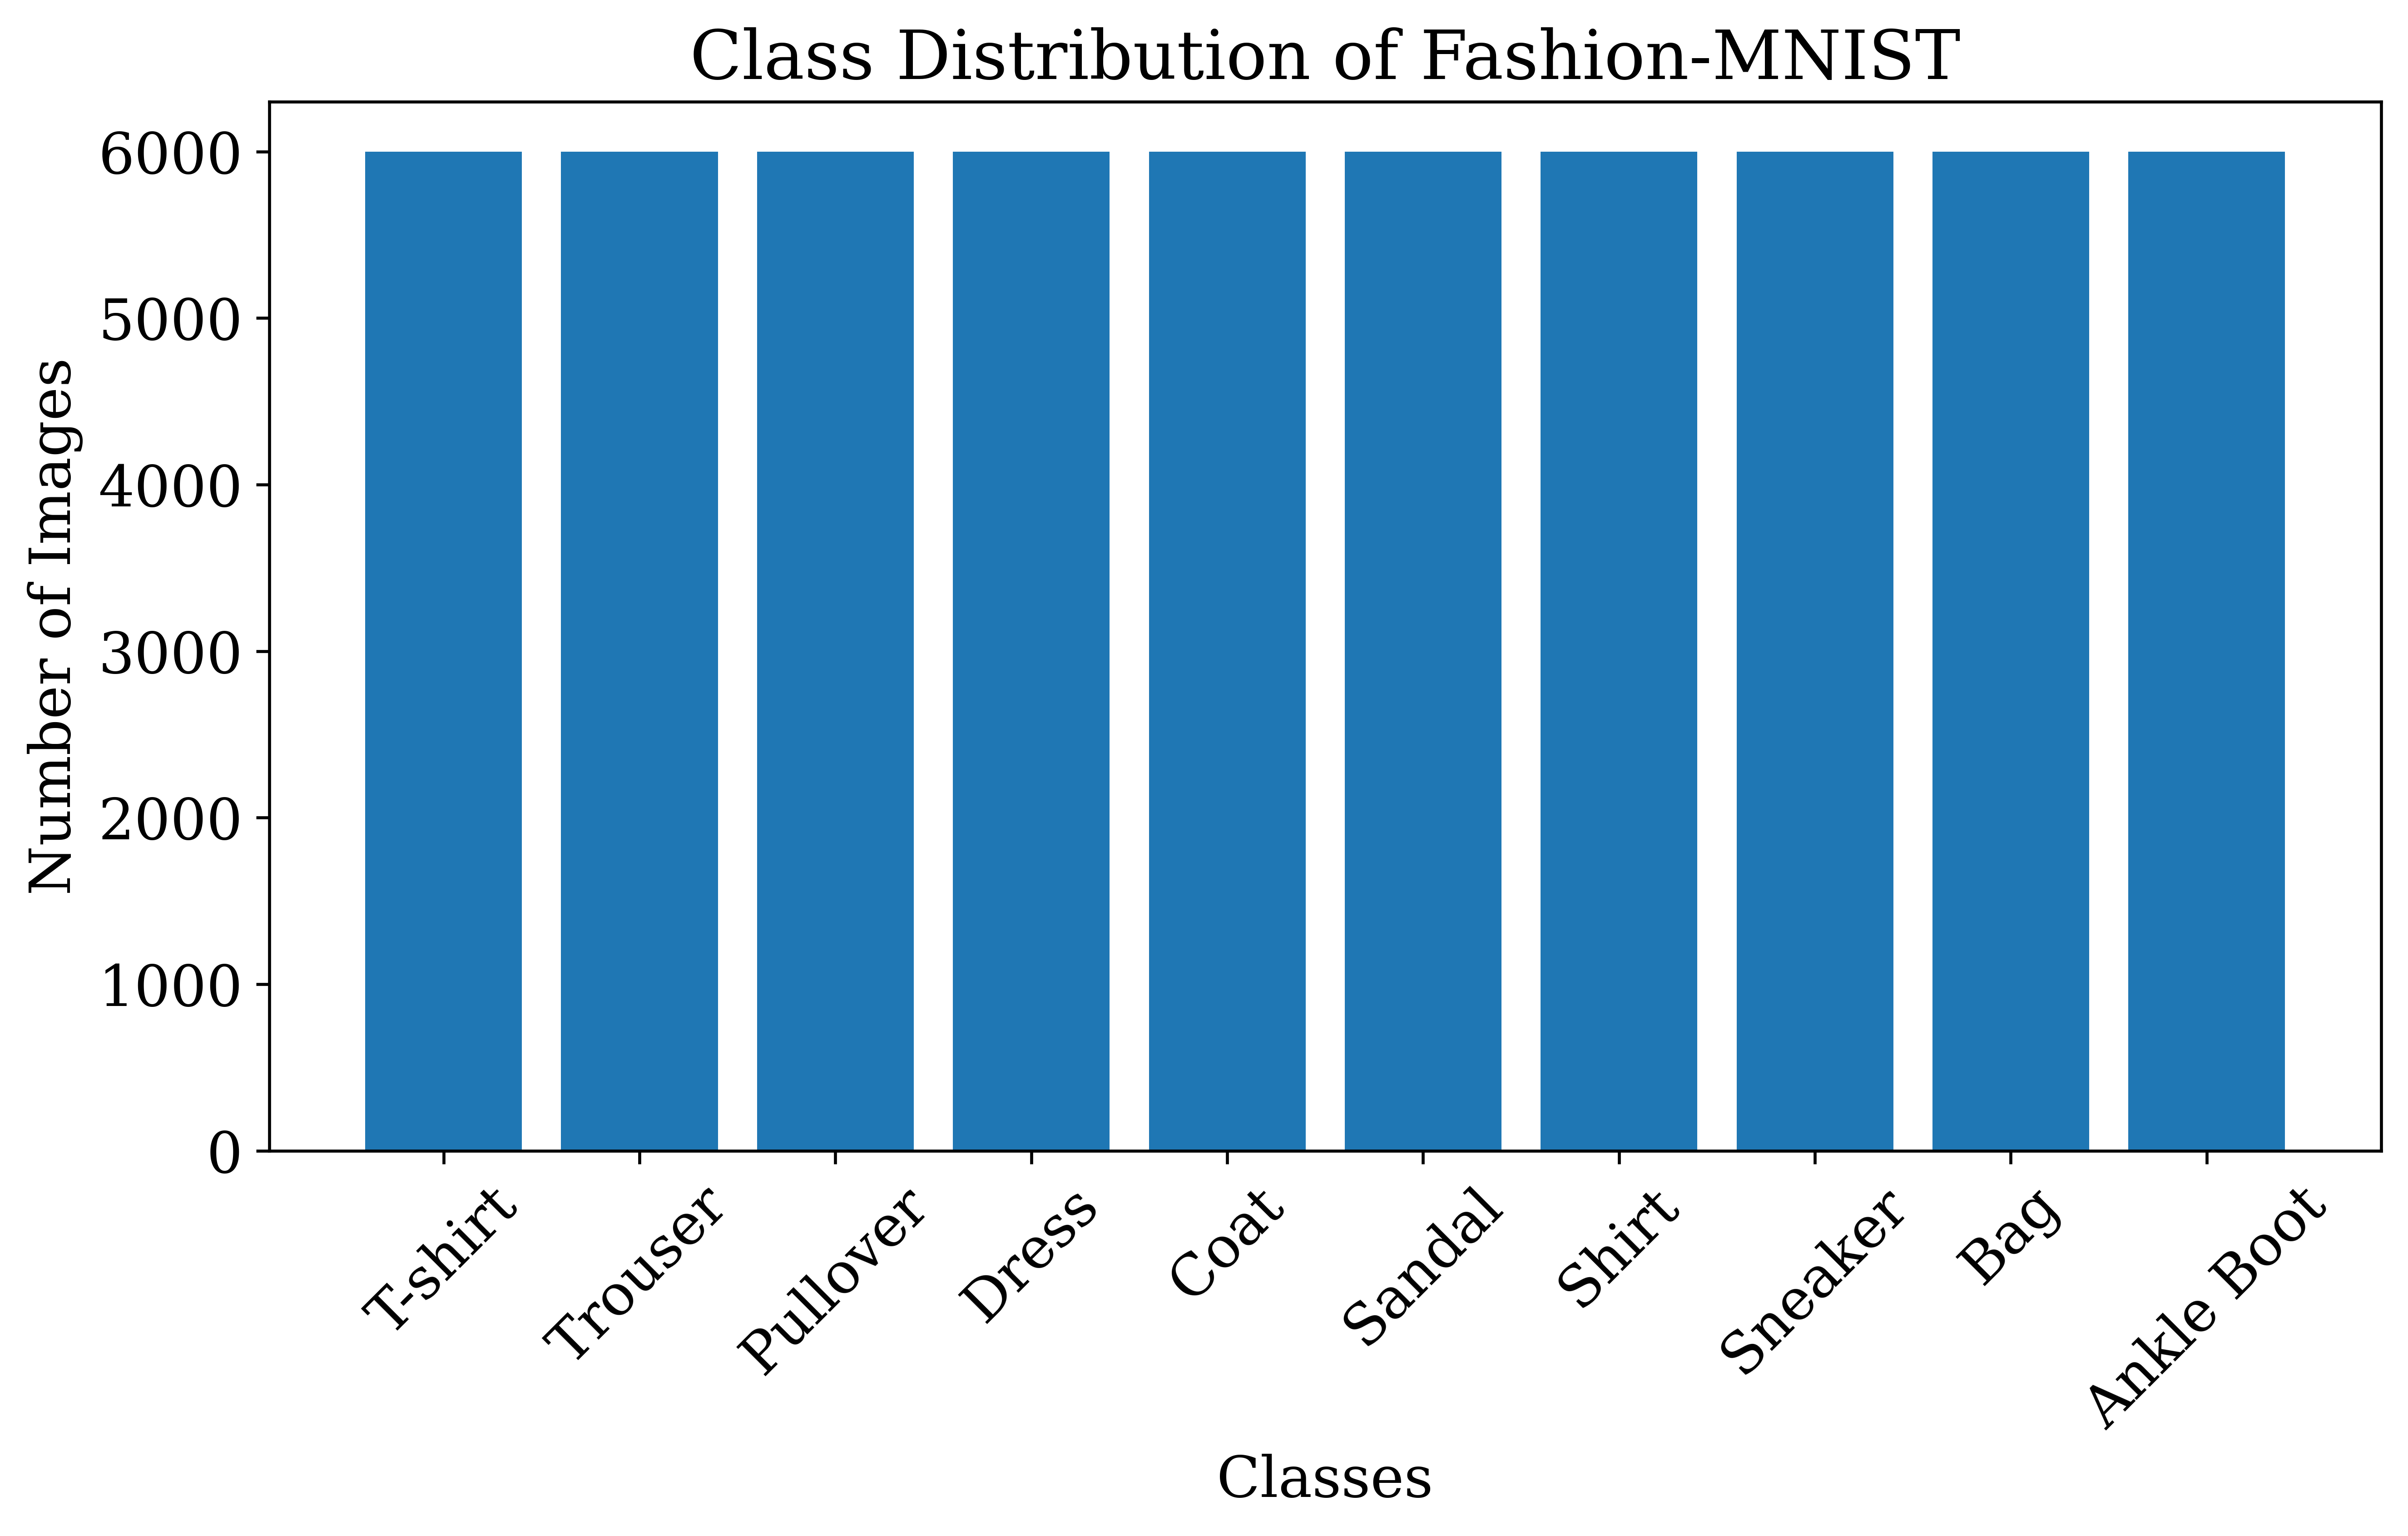

<Figure size 3840x2880 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Class Distribution of Fashion-MNIST")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.savefig(
    "Class_Distribution.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
display(X_train_re.shape)
display(X_test_re.shape)
display(Y_train_cat.shape)
display(Y_test_cat.shape)

(60000, 784)

(10000, 784)

(60000, 10)

(10000, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(128,activation="relu",input_shape=(784,)))
model.add(Dense(64,activation="relu"))
model.add(Dense(10,activation="softmax"))
model.summary()

model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

history=model.fit(X_train_re,Y_train_cat,epochs=20,batch_size=32,validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8165 - loss: 0.5163 - val_accuracy: 0.8403 - val_loss: 0.4422
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8610 - loss: 0.3824 - val_accuracy: 0.8551 - val_loss: 0.3901
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8732 - loss: 0.3433 - val_accuracy: 0.8742 - val_loss: 0.3538
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8816 - loss: 0.3186 - val_accuracy: 0.8704 - val_loss: 0.3421
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8895 - loss: 0.2990 - val_accuracy: 0.8852 - val_loss: 0.3249
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8947 - loss: 0.2836 - val_accuracy: 0.8795 - val_loss: 0.3351
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8987 - loss: 0.2709 - val_accuracy: 0.8792 - val_loss: 0.3367
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9021 - loss: 0.2586 - 

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test_re,Y_test_cat)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8877 - loss: 0.3792
Test Loss: 0.37919989228248596
Test Accuracy: 0.8877000212669373


In [ ]:
Y_test_prob=model.predict(X_test_re)
display(Y_test_prob)
Y_pred=np.argmax(Y_test_prob,axis=1)
display(Y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.2154521e-12, 1.0860781e-08, 2.3164263e-07, ..., 3.2902139e-04,
        1.3801588e-09, 9.9966097e-01],
       [4.6701125e-06, 3.9764402e-19, 9.9985397e-01, ..., 1.7487574e-15,
        7.1143661e-13, 1.7702140e-16],
       [1.1158215e-18, 1.0000000e+00, 2.5438843e-24, ..., 1.0260363e-39,
        3.2824085e-19, 9.3783665e-33],
       ...,
       [3.2377079e-06, 8.9568604e-12, 9.1111609e-08, ..., 1.4593964e-10,
        9.9999535e-01, 1.1506376e-13],
       [1.5239739e-16, 1.0000000e+00, 9.6938855e-16, ..., 4.7521473e-17,
        1.0835965e-12, 5.4963112e-18],
       [8.8305558e-09, 4.1066382e-12, 5.3772942e-09, ..., 1.4713230e-07,
        8.5918916e-09, 1.5031999e-12]], dtype=float32)

(10000,)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

test_loss,test_accuracy=model.evaluate(X_test_re, Y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predict probabilities
Y_pred_prob = model.predict(X_test_re)

# Convert probabilities to class labels
Y_pred = np.argmax(Y_pred_prob, axis=1)

# Convert one-hot labels back to integers
Y_true = np.argmax(Y_test_cat, axis=1)

# Metrics
accuracy = accuracy_score(Y_true, Y_pred)
precision = precision_score(Y_true, Y_pred, average="weighted")
recall = recall_score(Y_true, Y_pred, average="weighted")
f1 = f1_score(Y_true, Y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8877 - loss: 0.3792
Test Loss: 0.37919989228248596
Test Accuracy: 0.8877000212669373
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8877
Precision: 0.8877
Recall   : 0.8877
F1-score : 0.8874

Confusion Matrix:
[[852   2  15  20   7   1  99   0   4   0]
 [  3 970   2  20   3   0   2   0   0   0]
 [ 17   0 804  13  92   0  74   0   0   0]
 [ 24   2  17 904  28   0  21   0   4   0]
 [  2   0  77  34 833   0  48   0   6   0]
 [  0   0   0   1   0 943   0  24   2  30]
 [141   2  75  26  69   0 678   0   9   0]
 [  0   0   0   0   0   3   0 976   1  20]
 [  5   0   4   3   5   2   5   2 974   0]
 [  0   1   0   0   0   3   1  52   0 943]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.80      0.81      1000
           3       0.89      0.90      0.89      1000
  

In [ ]:
!pip install scikeras

In [ ]:
!pip install scikit-learn==1.5.2

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):

    model = Sequential()

    # Input Layer
    model.add(Input(shape=(784,)))

    # First Hidden Layer
    model.add(Dense(hidden_neurons, activation=activation))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Additional Hidden Layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(hidden_neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output Layer
    model.add(Dense(10, activation="softmax"))

    # Optimizer Selection
    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == "rmsprop":
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# SciKeras Wrapper
mlp = KerasClassifier(
    model=create_model,
    verbose=0
)


# Hyperparameter Search Space (Lab Manual)
param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}


# Randomized Search
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=5 ,          # You can change to 10 if you have enough time
    cv=5,              # Required by the lab manual
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)


# Start Hyperparameter Search
random_search.fit(X_train_re, Y_train_cat)


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7b9daea9cd60>, verbose=0),
                   n_iter=5, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['sgd', 'adam',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy')

In [ ]:
import sklearn
import scikeras

print(sklearn.__version__)
print(scikeras.__version__)

1.5.2
0.13.0


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU Name:", tf.test.gpu_device_name())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
GPU Name: /device:GPU:0


In [ ]:
!nvidia-smi

Fri Jul 24 12:34:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     639MiB /  15360MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8889833333333333


In [ ]:
best_model = create_model(
    hidden_layers=3,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer="rmsprop",
    activation="tanh",
    dropout_rate=0.2
)

history_best = best_model.fit(
    X_train_re,
    Y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7883 - loss: 0.5841 - val_accuracy: 0.8242 - val_loss: 0.4901
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8367 - loss: 0.4537 - val_accuracy: 0.8304 - val_loss: 0.4720
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8494 - loss: 0.4208 - val_accuracy: 0.8580 - val_loss: 0.4045
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8592 - loss: 0.3947 - val_accuracy: 0.8587 - val_loss: 0.3943
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8632 - loss: 0.3813 - val_accuracy: 0.8652 - val_loss: 0.3776
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8688 - loss: 0.3661 - val_accuracy: 0.8724 - val_loss: 0.3614
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8724 - loss: 0.3579 - val_accuracy: 0.8754 - val_loss: 0.3516
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8758 - loss: 0.3495 - 

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Y_pred_prob_opti = best_model.predict(X_test_re)
Y_pred_opti = np.argmax(Y_pred_prob_opti, axis=1)
Y_true_opti = np.argmax(Y_test_cat, axis=1)

accuracy_opti = accuracy_score(Y_true_opti, Y_pred_opti)
precision_opti = precision_score(Y_true_opti, Y_pred_opti, average="weighted")
recall_opti = recall_score(Y_true_opti, Y_pred_opti, average="weighted")
f1_opti = f1_score(Y_true_opti, Y_pred_opti, average="weighted")

print("Accuracy :", accuracy_opti)
print("Precision :", precision_opti)
print("Recall :", recall_opti)
print("F1 Score :", f1_opti)

print("\nClassification Report\n")
print(classification_report(Y_true_opti, Y_pred_opti))

cm_opti = confusion_matrix(Y_true_opti, Y_pred_opti)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8747
Precision : 0.8781969261689272
Recall : 0.8747
F1 Score : 0.8747129809453394

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1000
           1       1.00      0.96      0.98      1000
           2       0.85      0.71      0.78      1000
           3       0.85      0.93      0.89      1000
           4       0.76      0.84      0.80      1000
           5       0.97      0.95      0.96      1000
           6       0.66      0.72      0.69      1000
           7       0.93      0.95      0.94      1000
           8       0.94      0.98      0.96      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



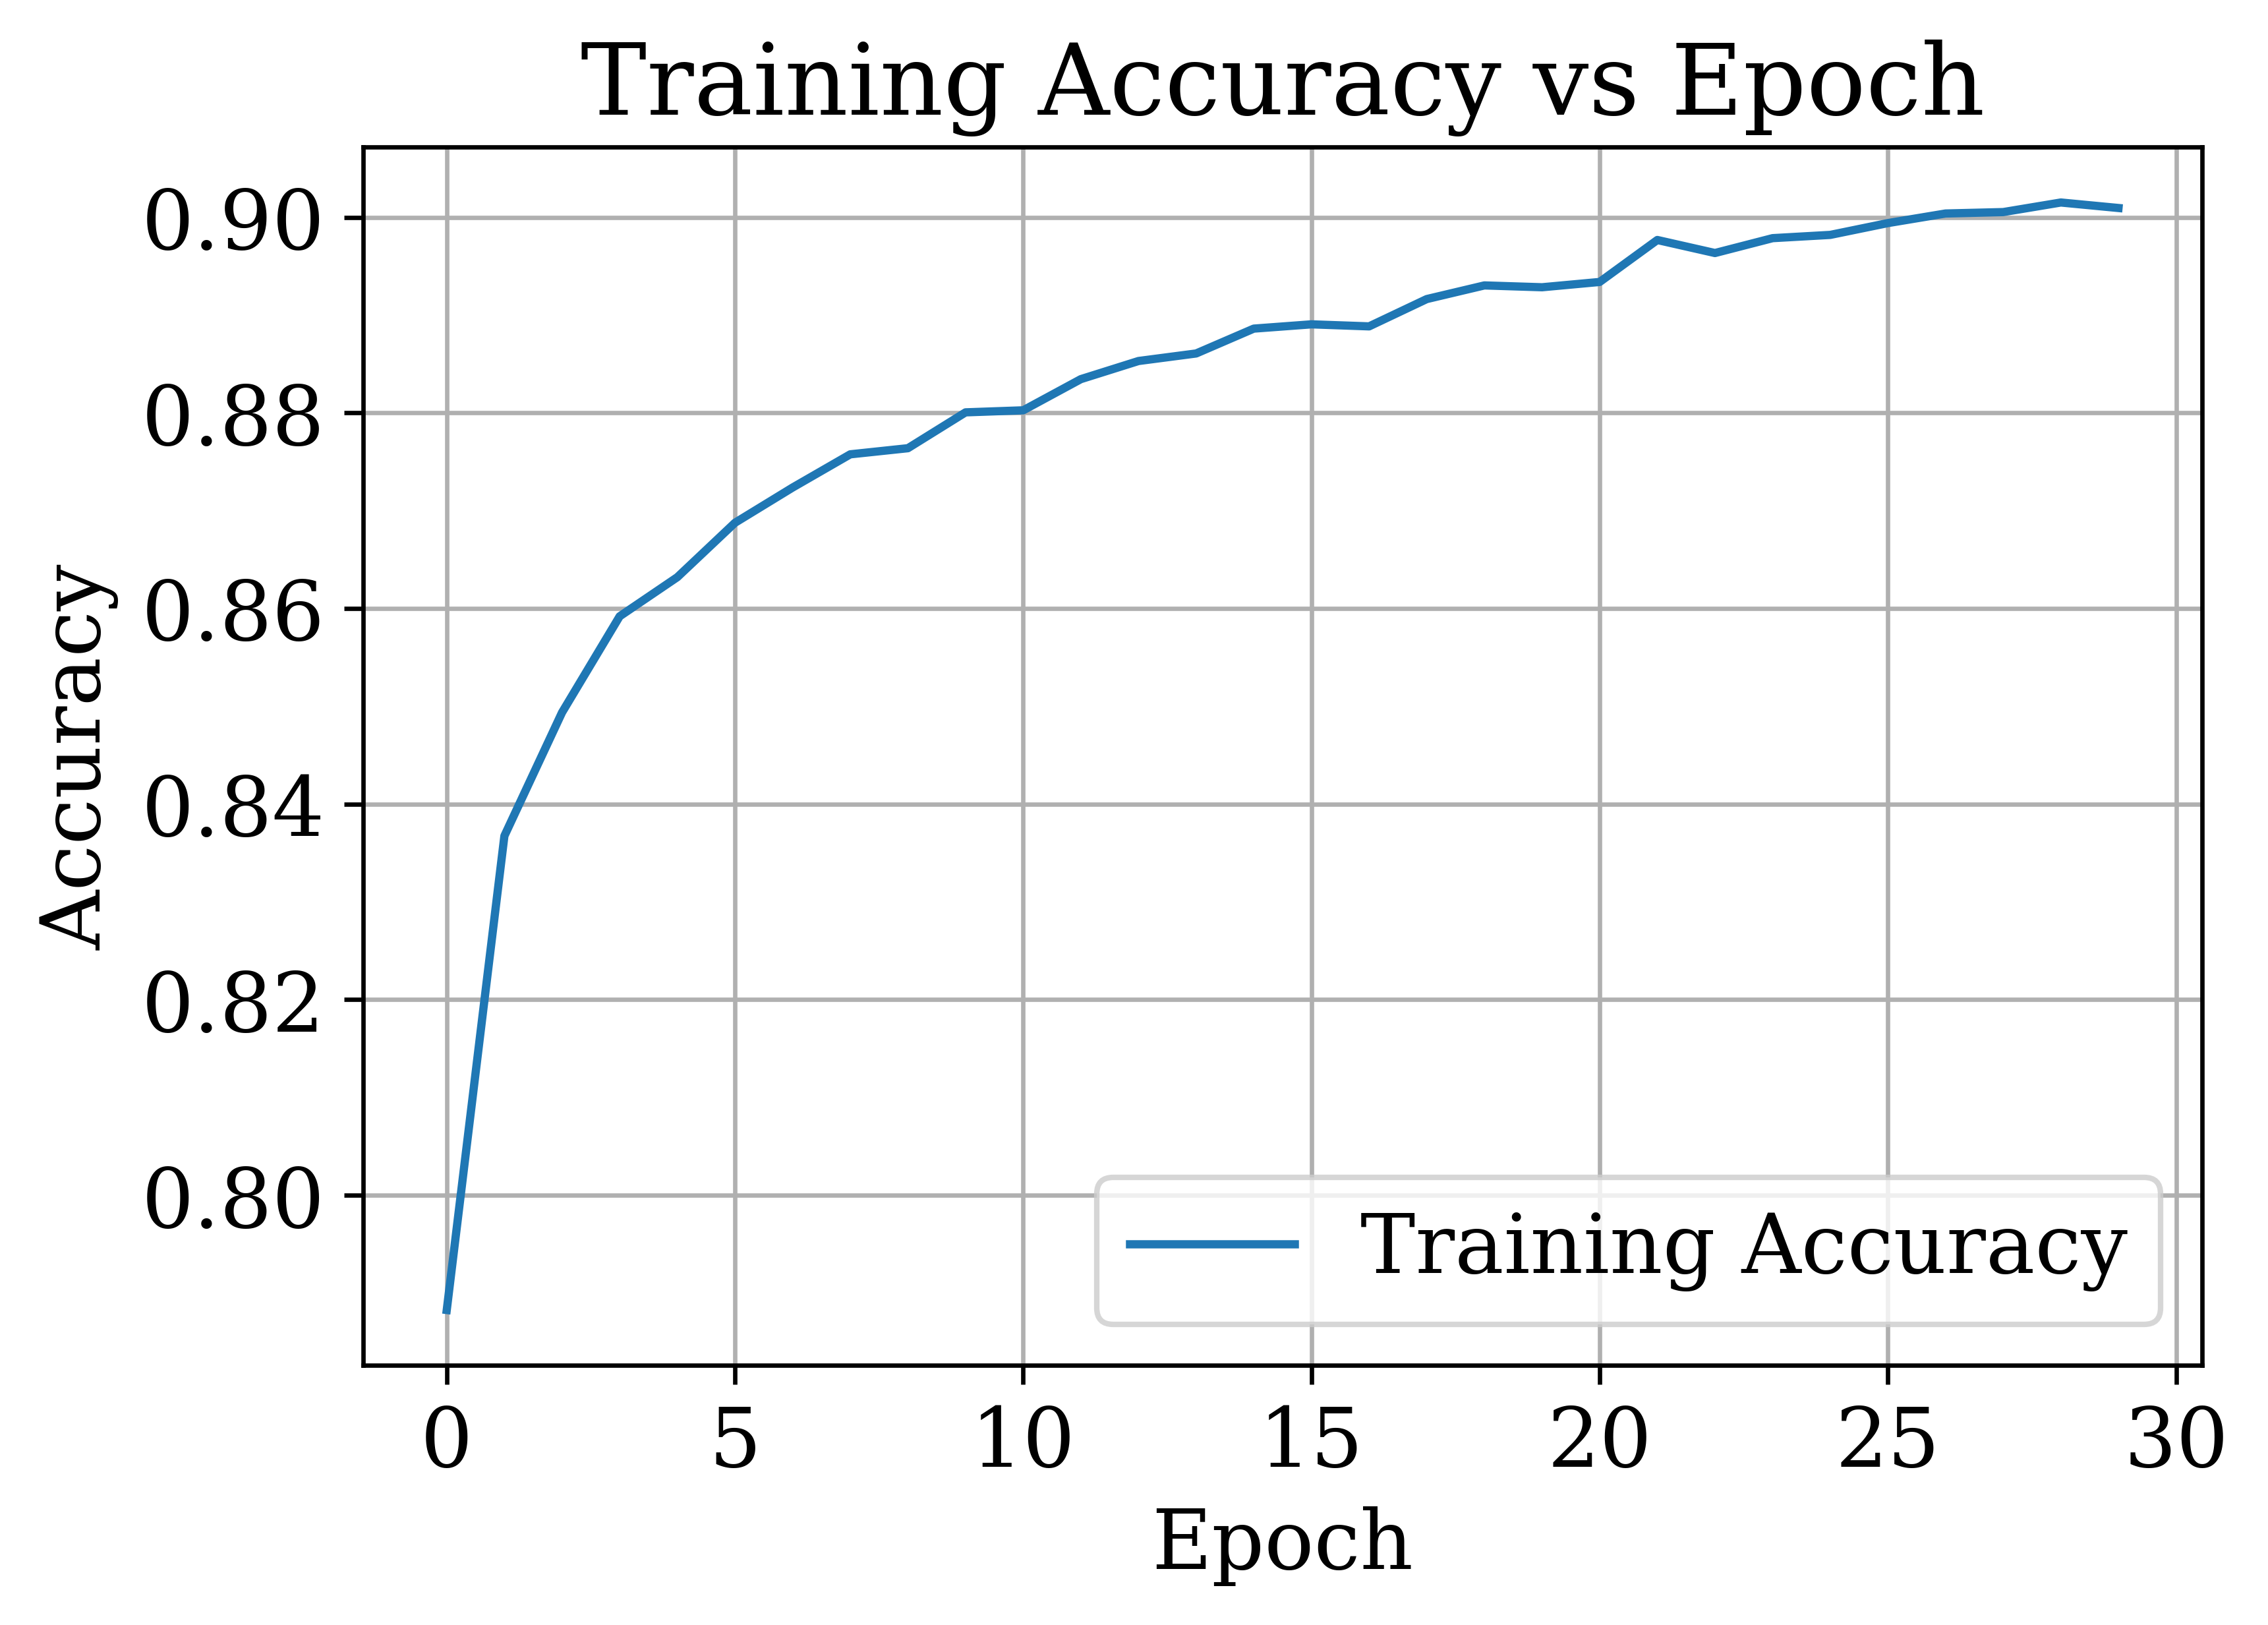

<Figure size 3840x2880 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig(
    "Training_Accuracy_vs_Epoch.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

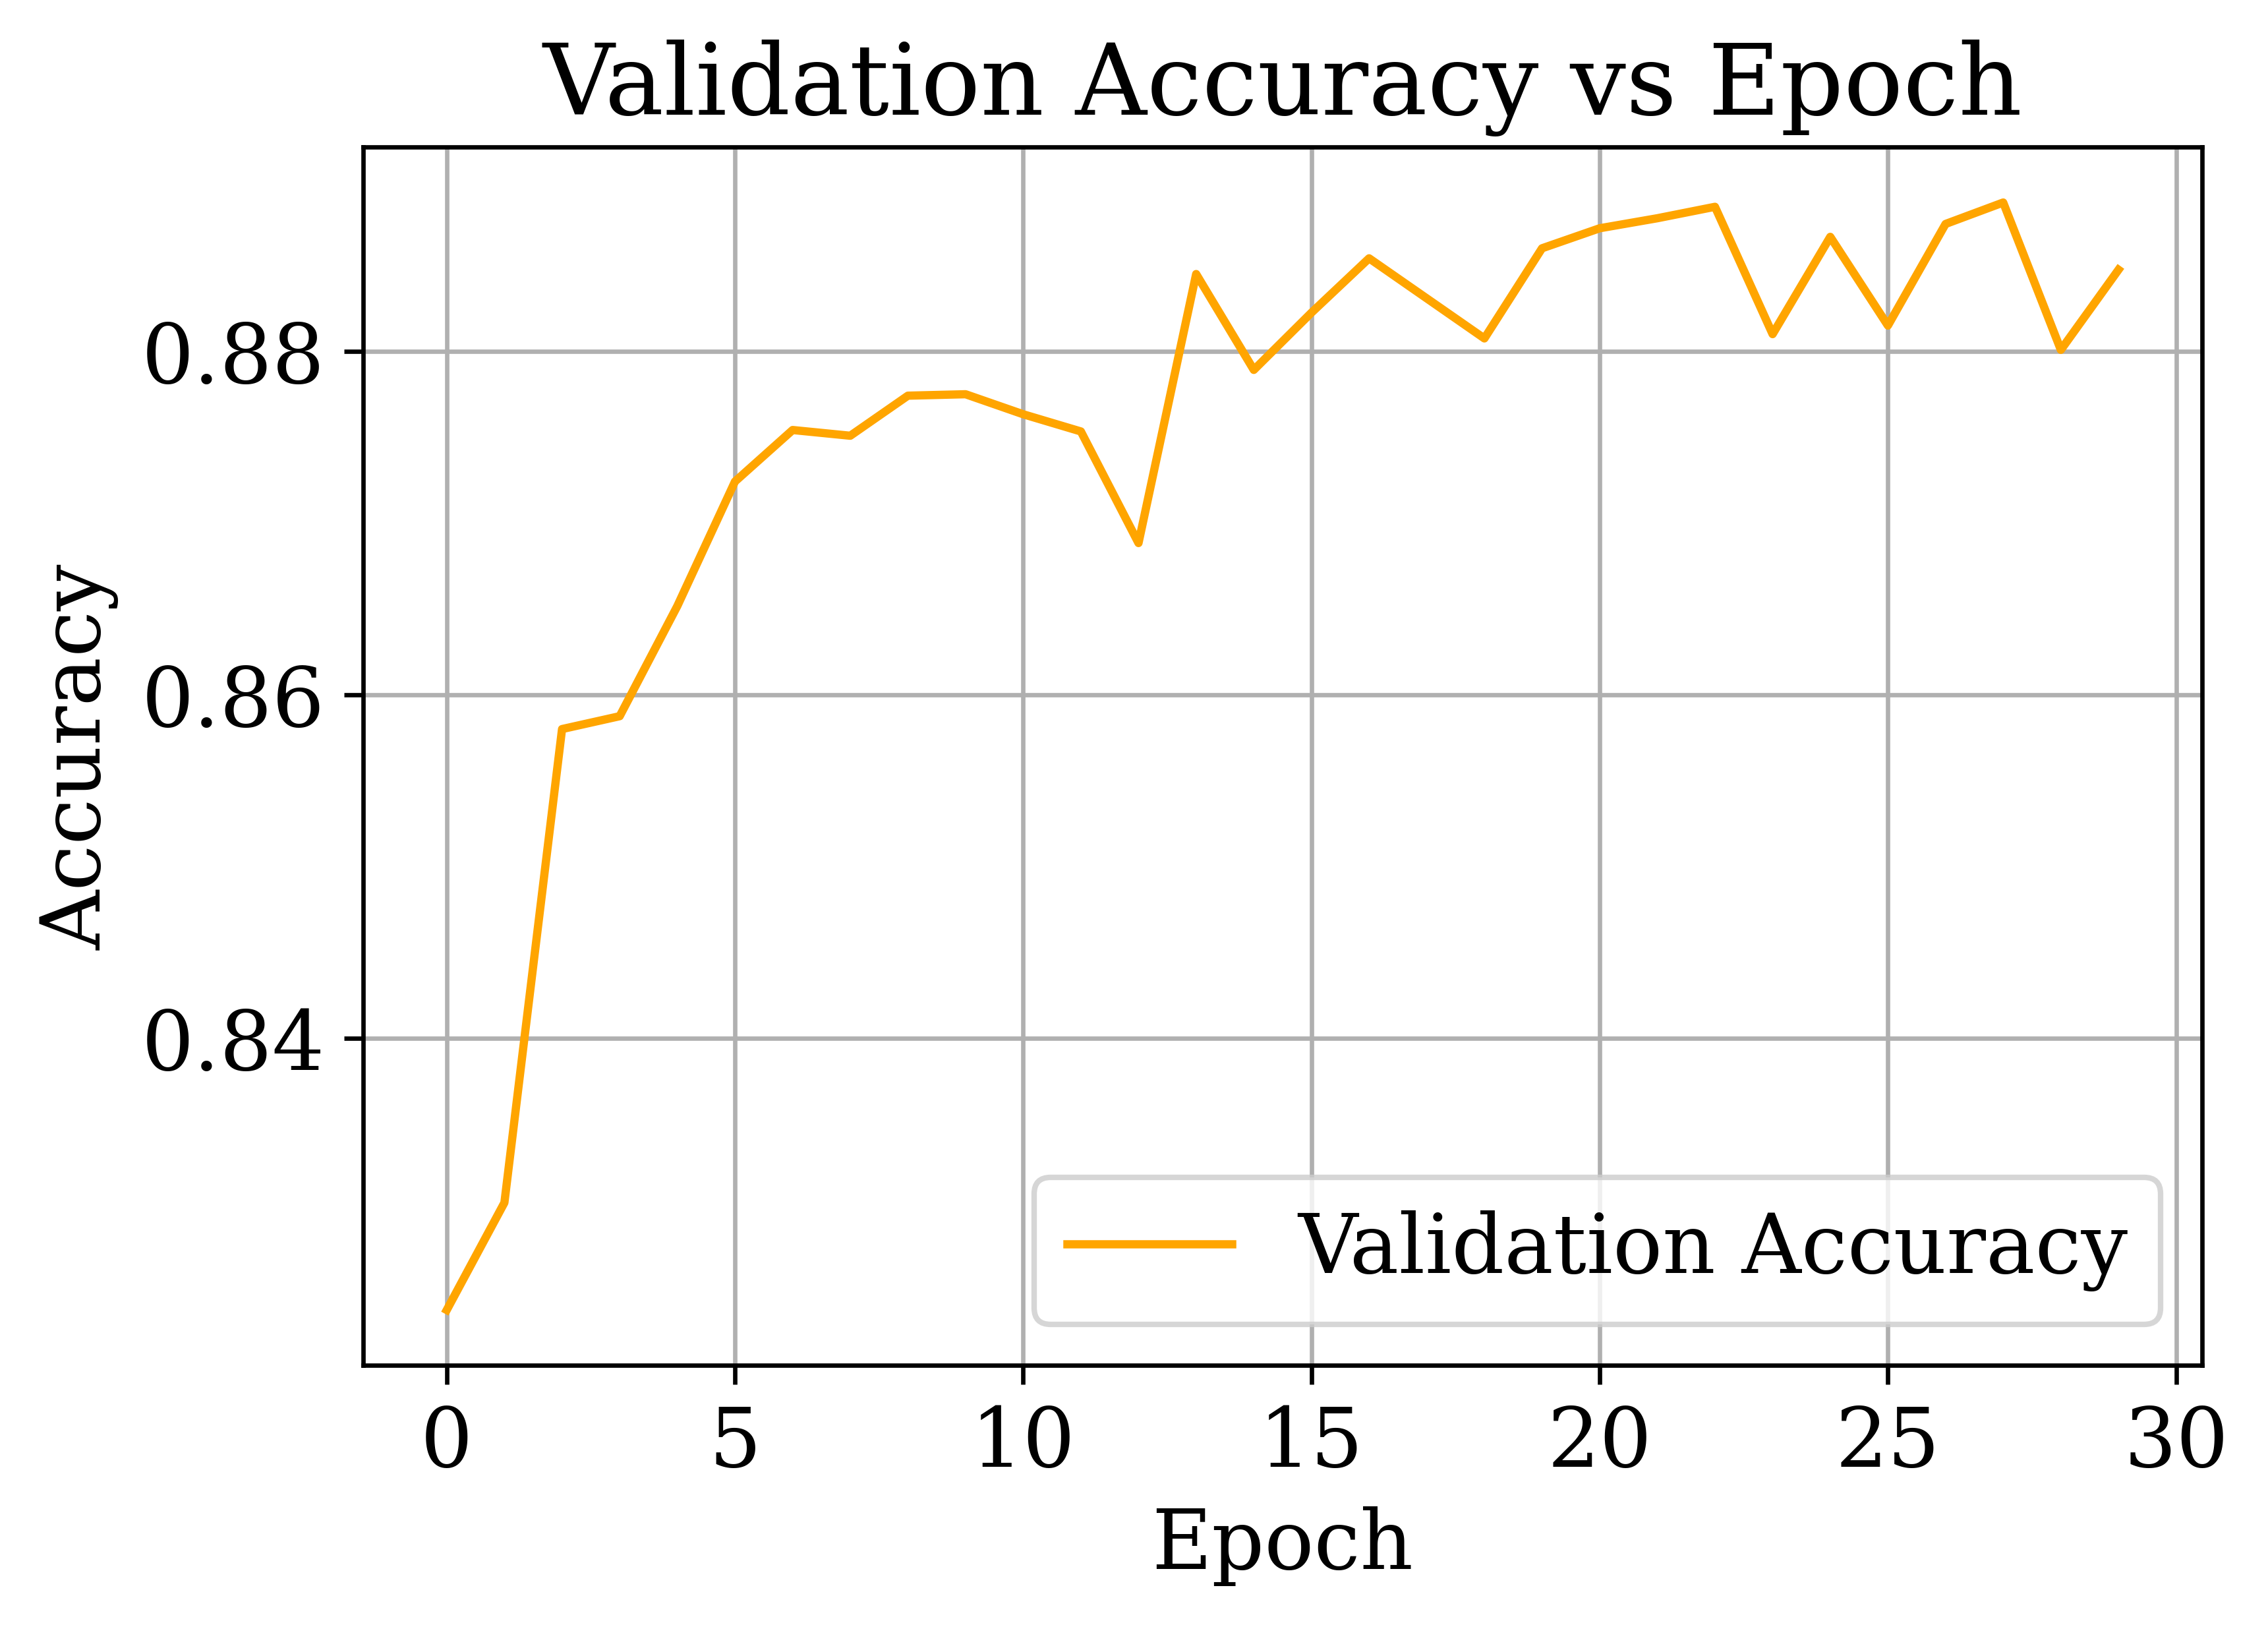

<Figure size 3840x2880 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig(
    "Validation_Accuracy_vs_Epoch.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


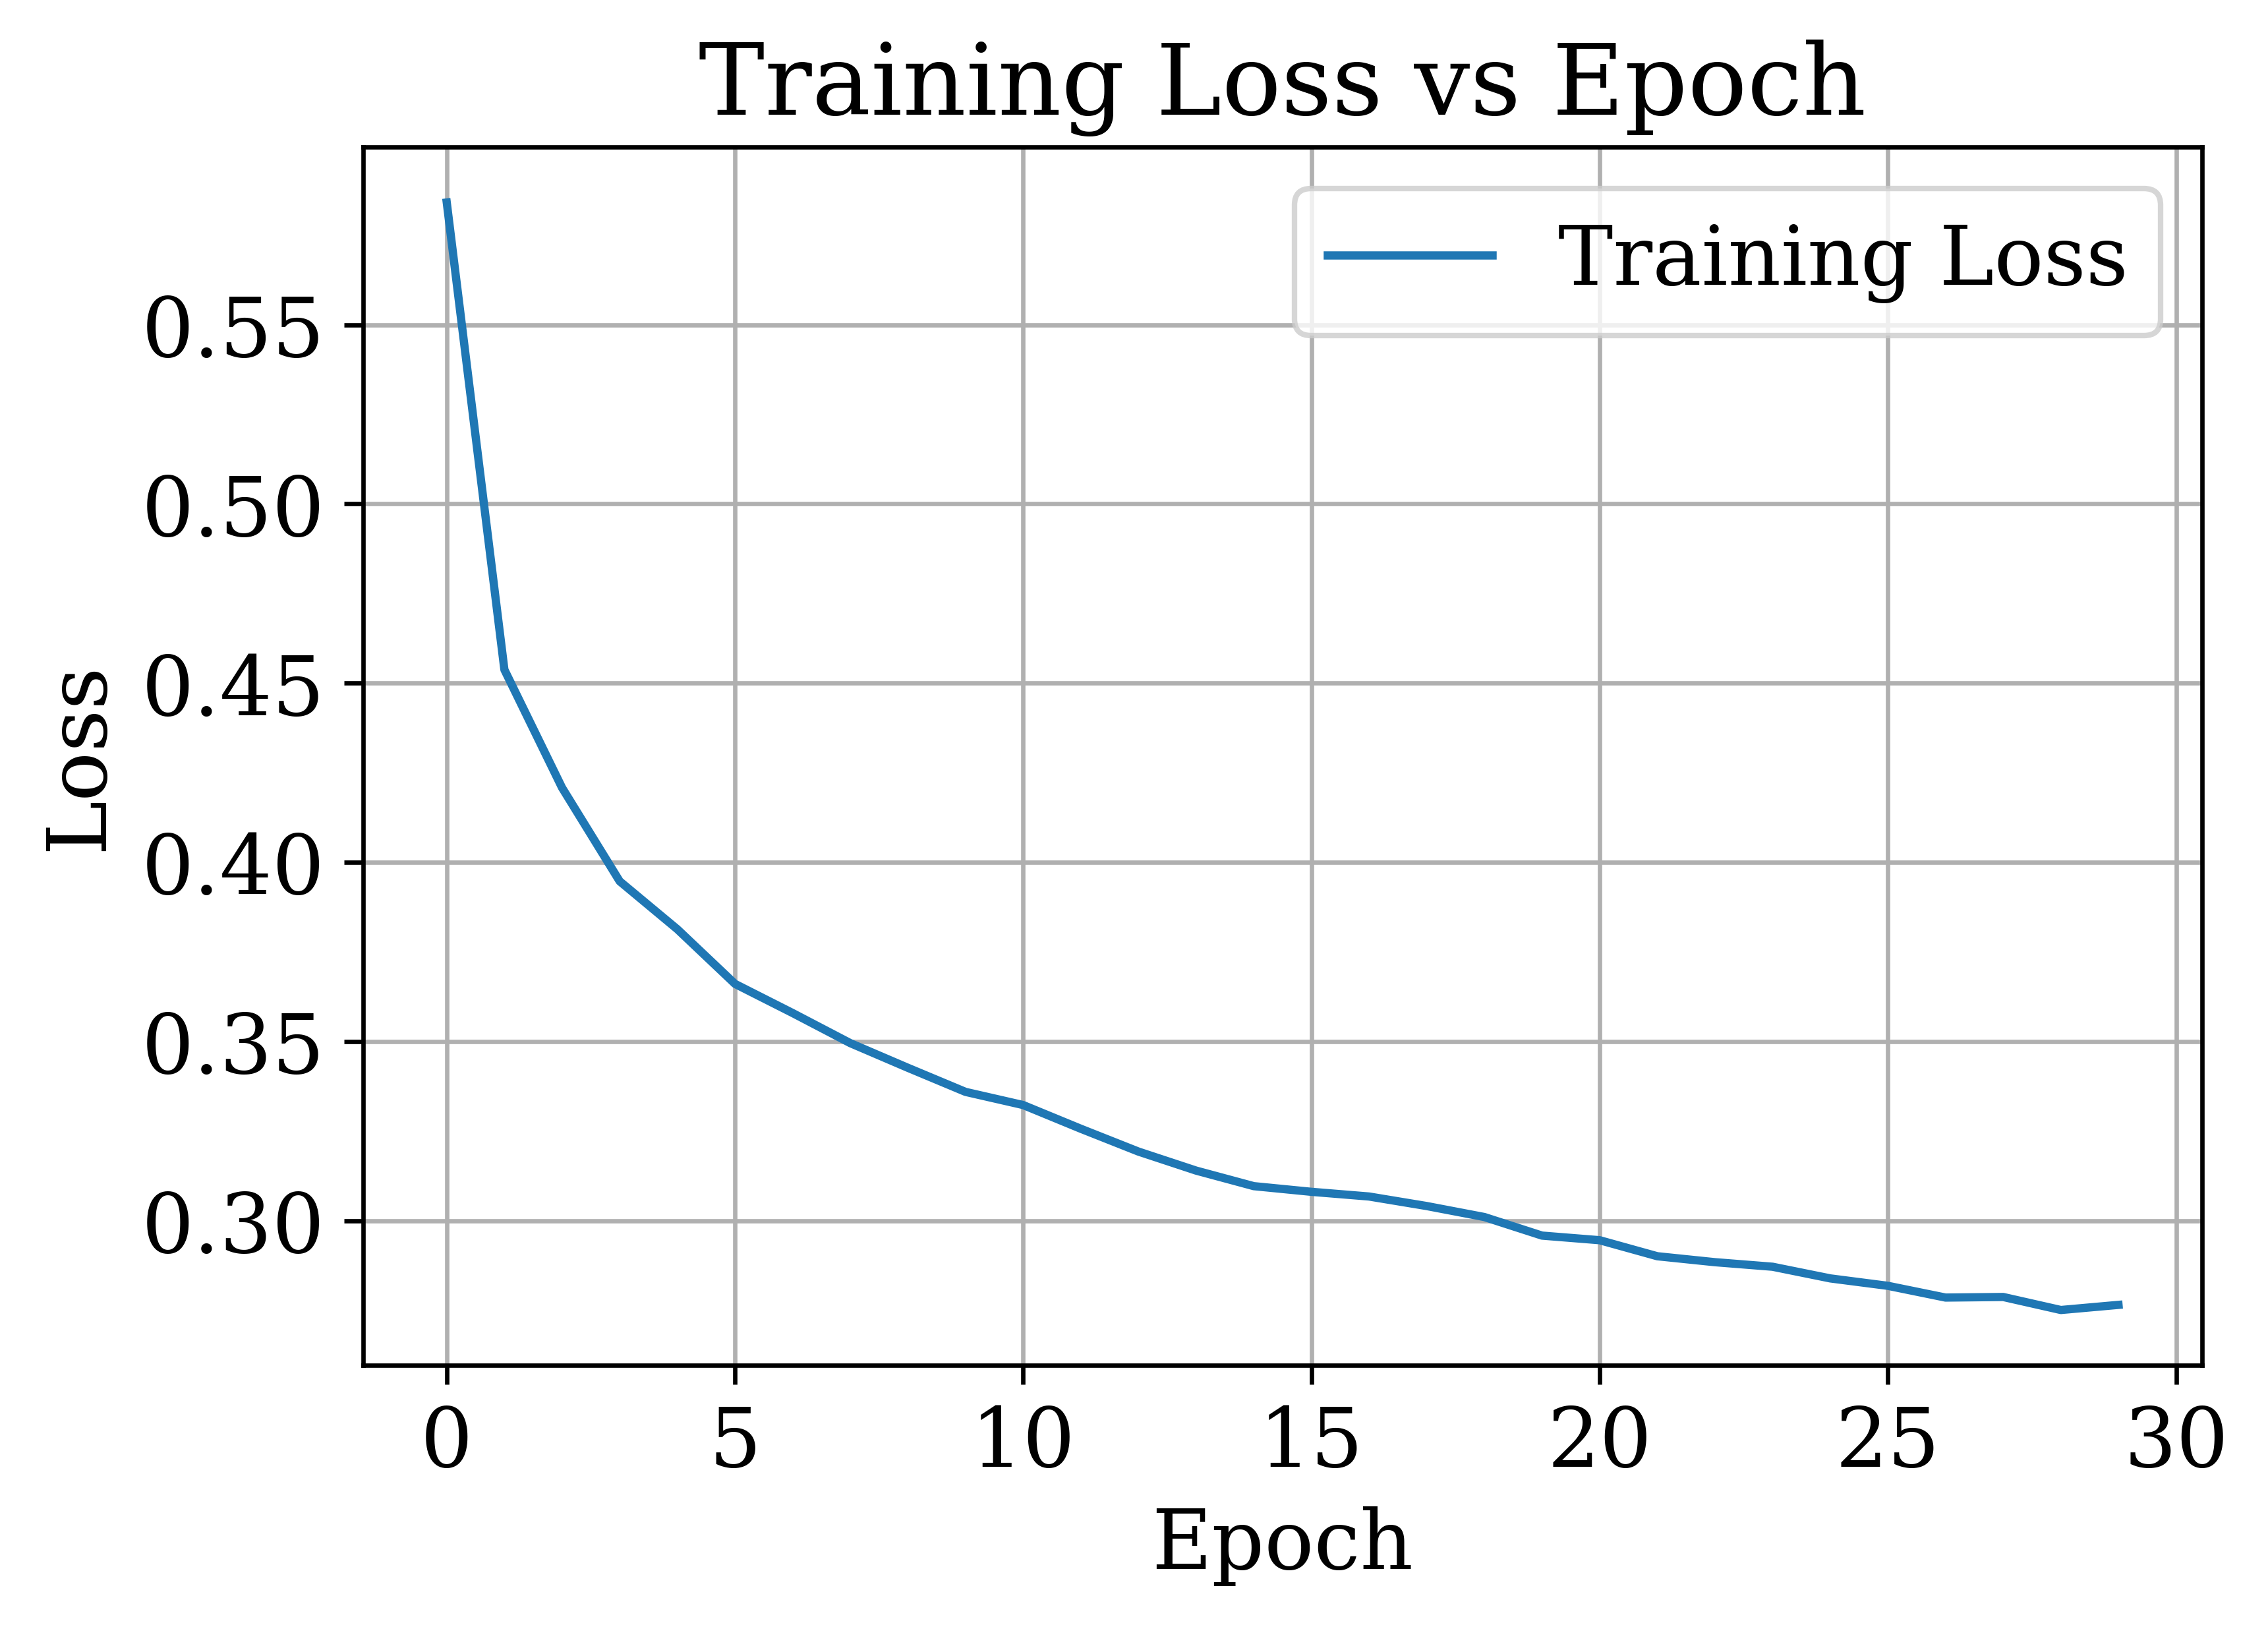

<Figure size 3840x2880 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_best.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig(
    "Training_loss_vs_Epoch.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

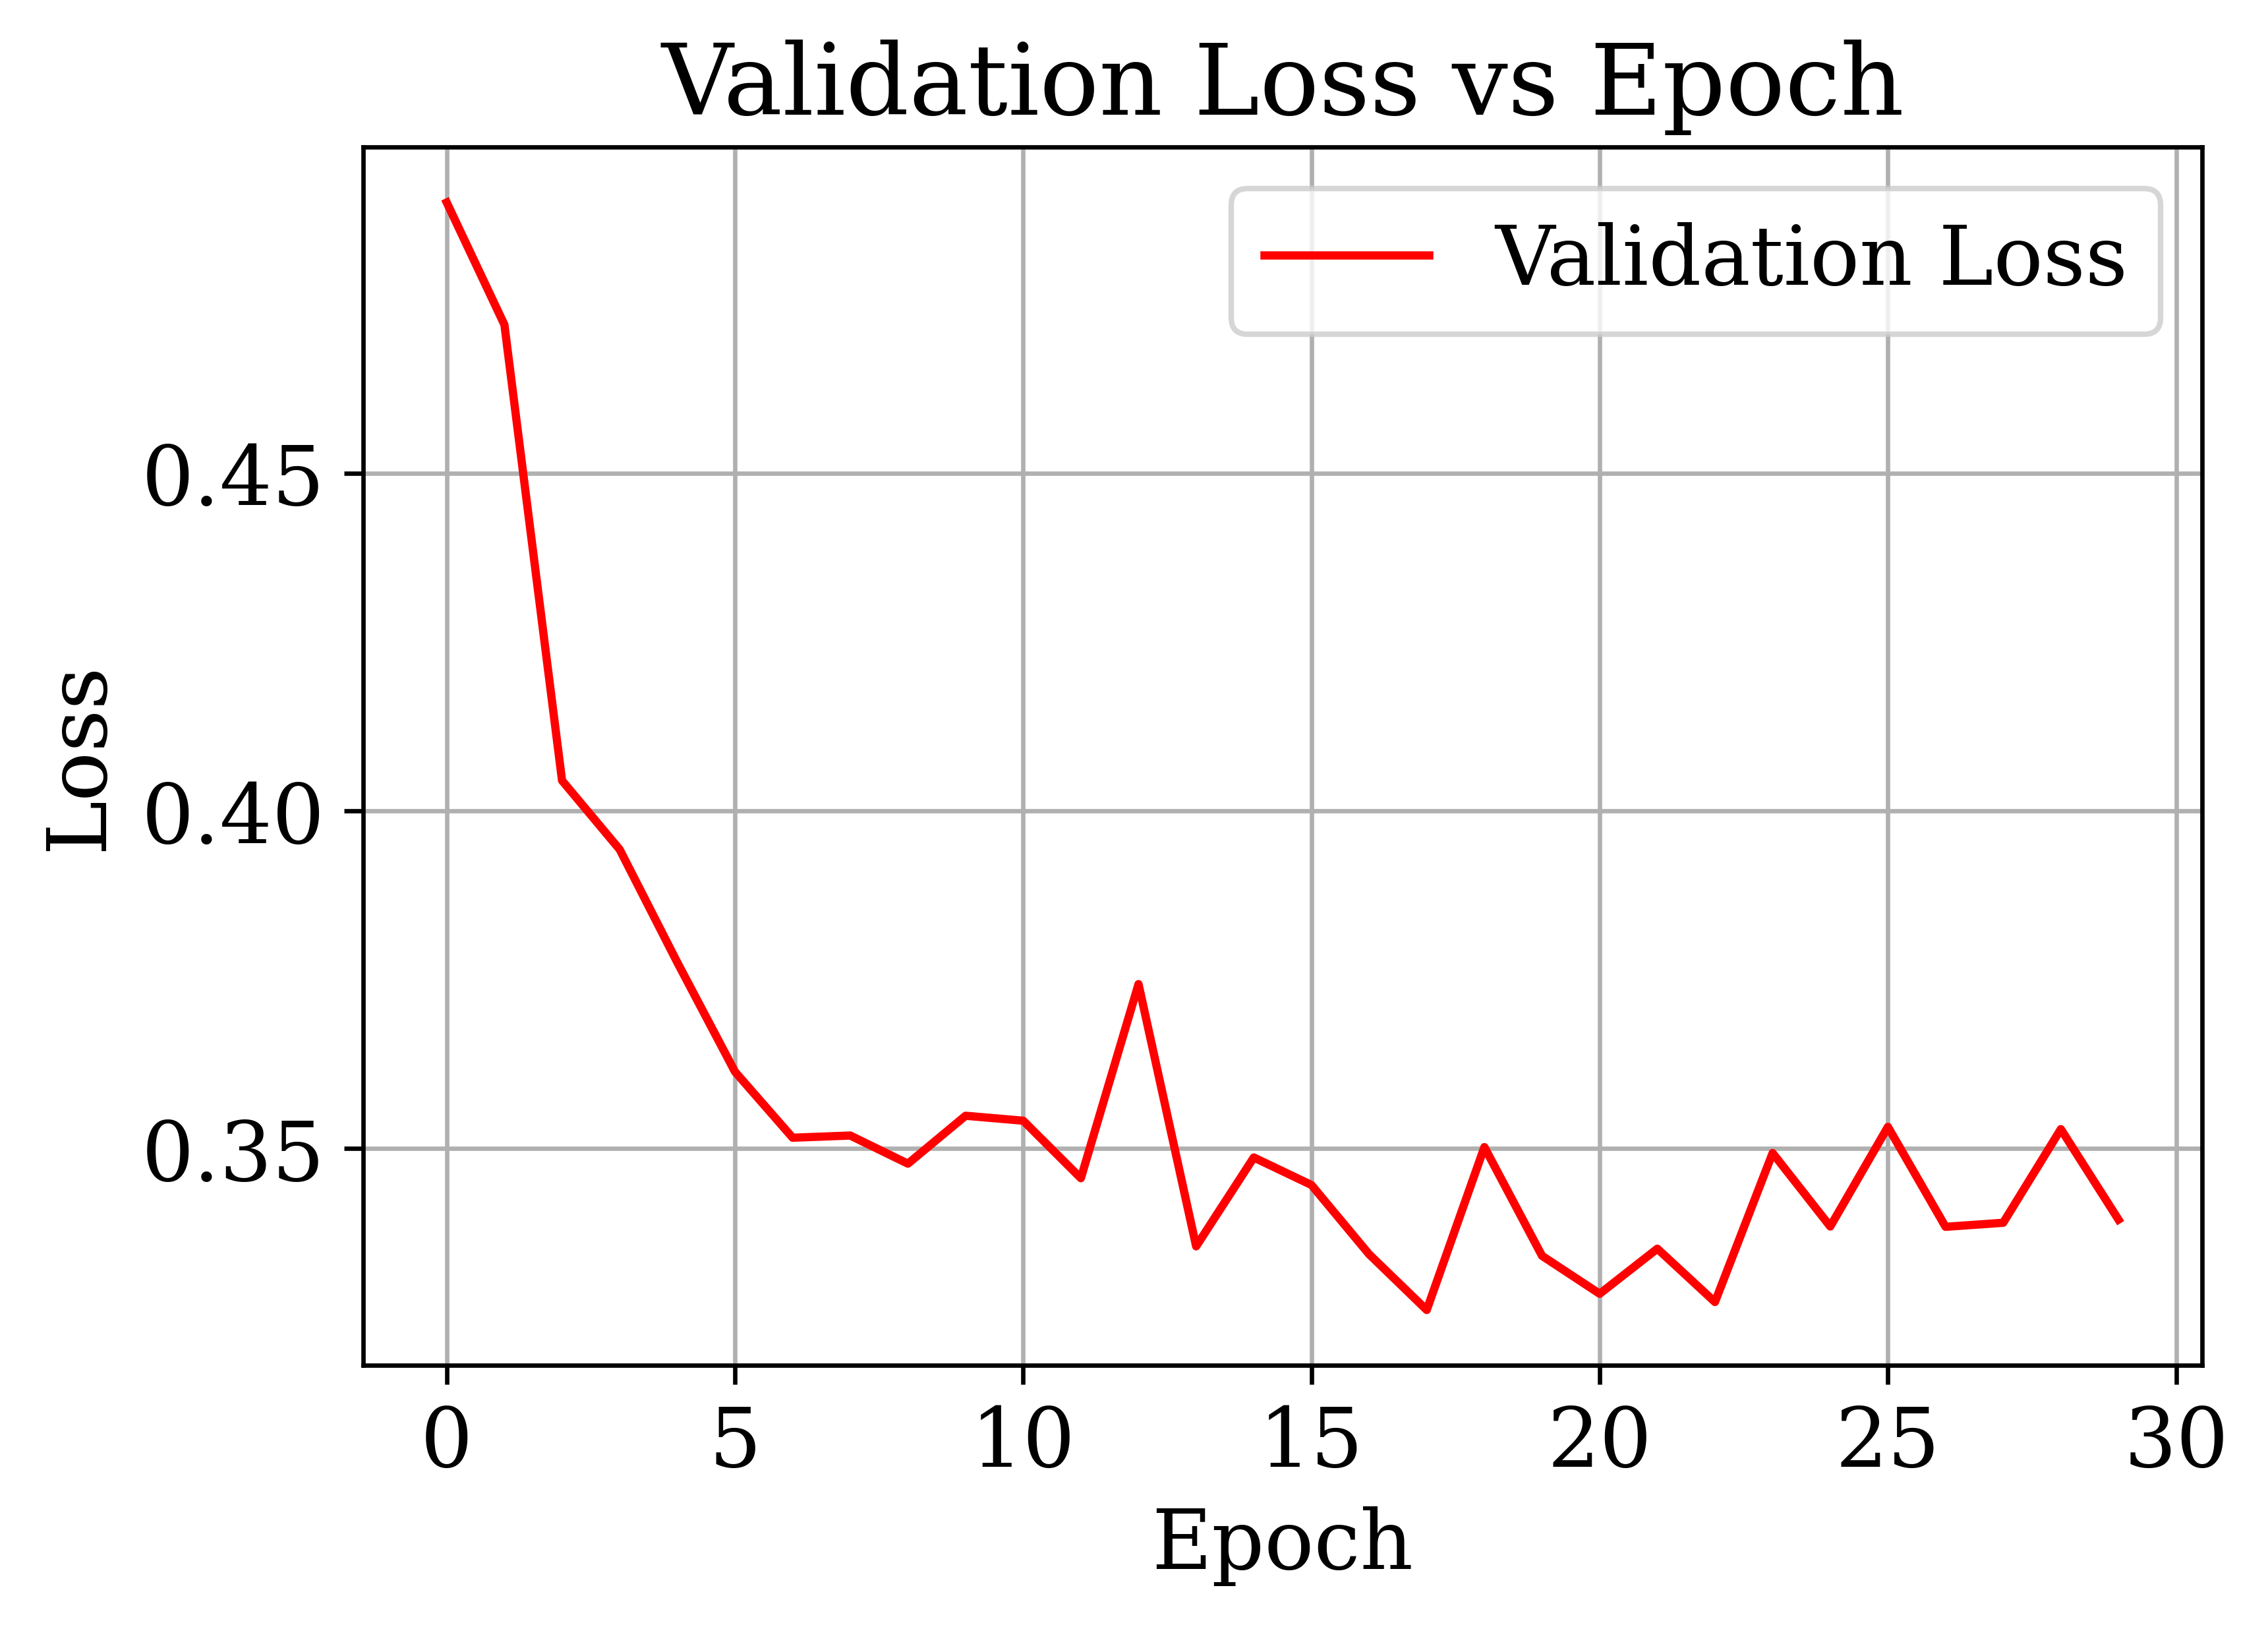

<Figure size 3840x2880 with 0 Axes>

In [ ]:


plt.figure(figsize=(6,4))
plt.plot(history_best.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig(
    "Validation_Loss_vs_Epoch.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

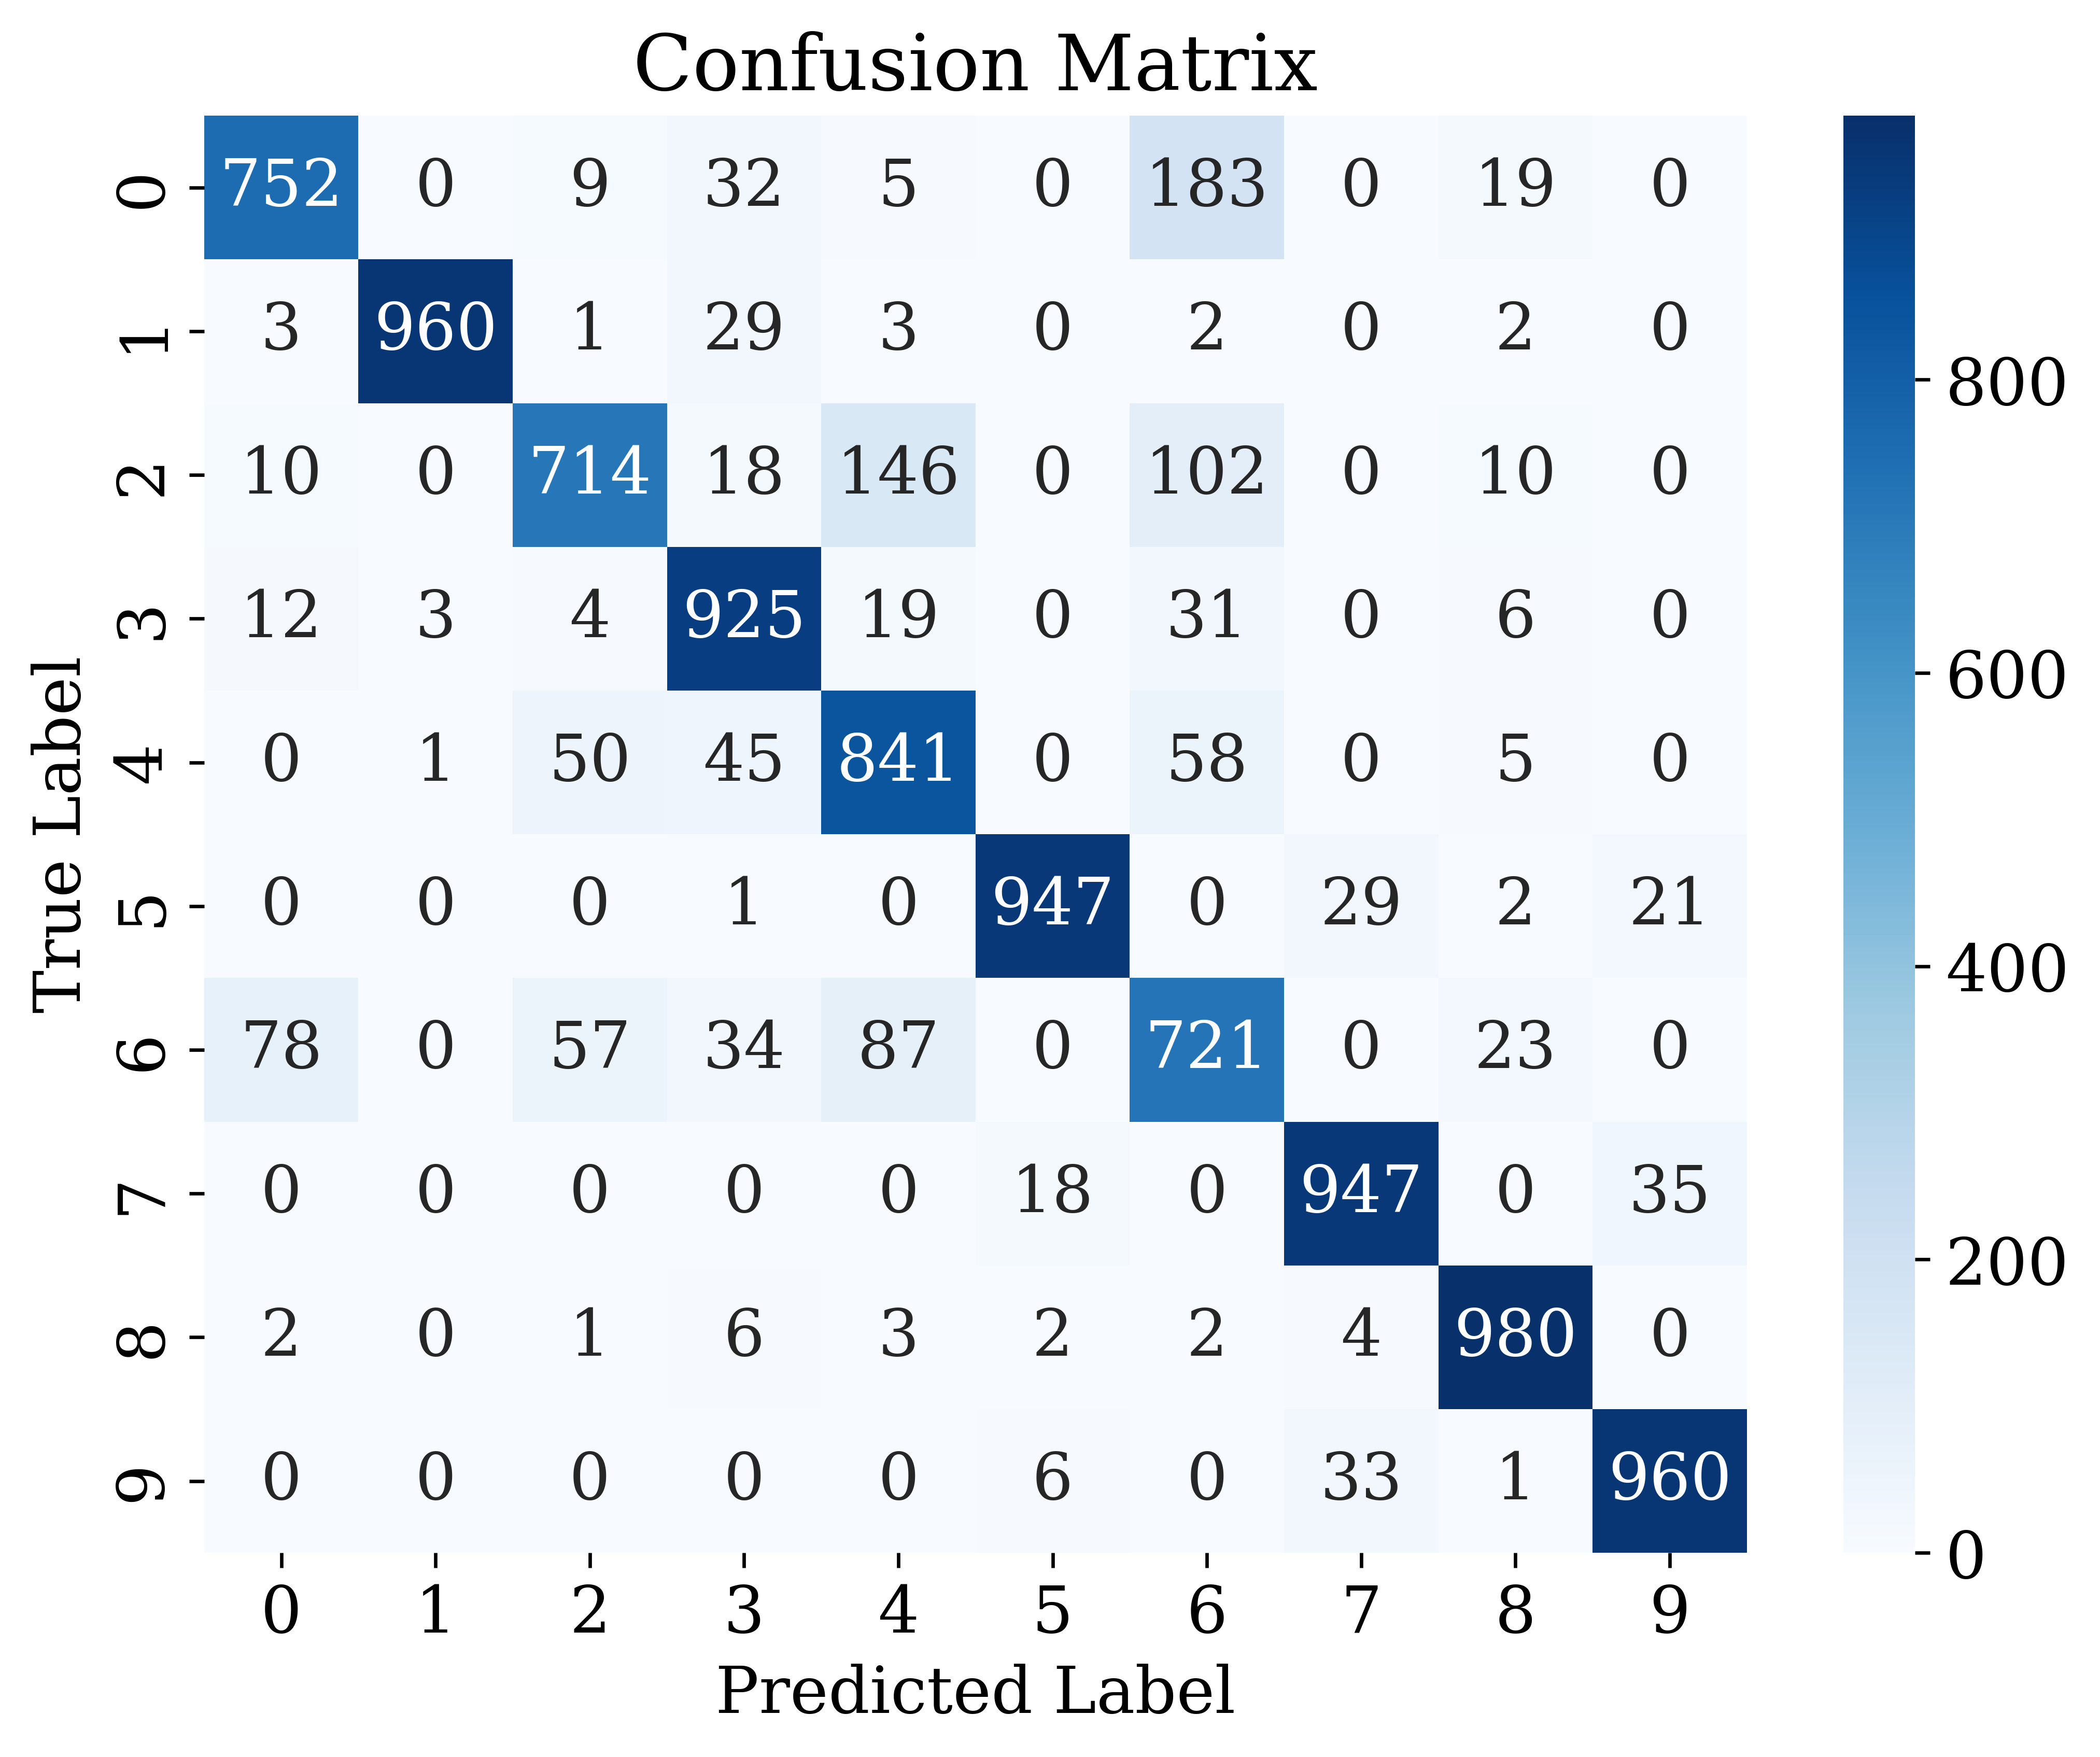

<Figure size 3840x2880 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_opti = confusion_matrix(Y_true_opti, Y_pred_opti)

plt.figure(figsize=(8,6))
sns.heatmap(cm_opti,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig(
    "Confusion_Matrix.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

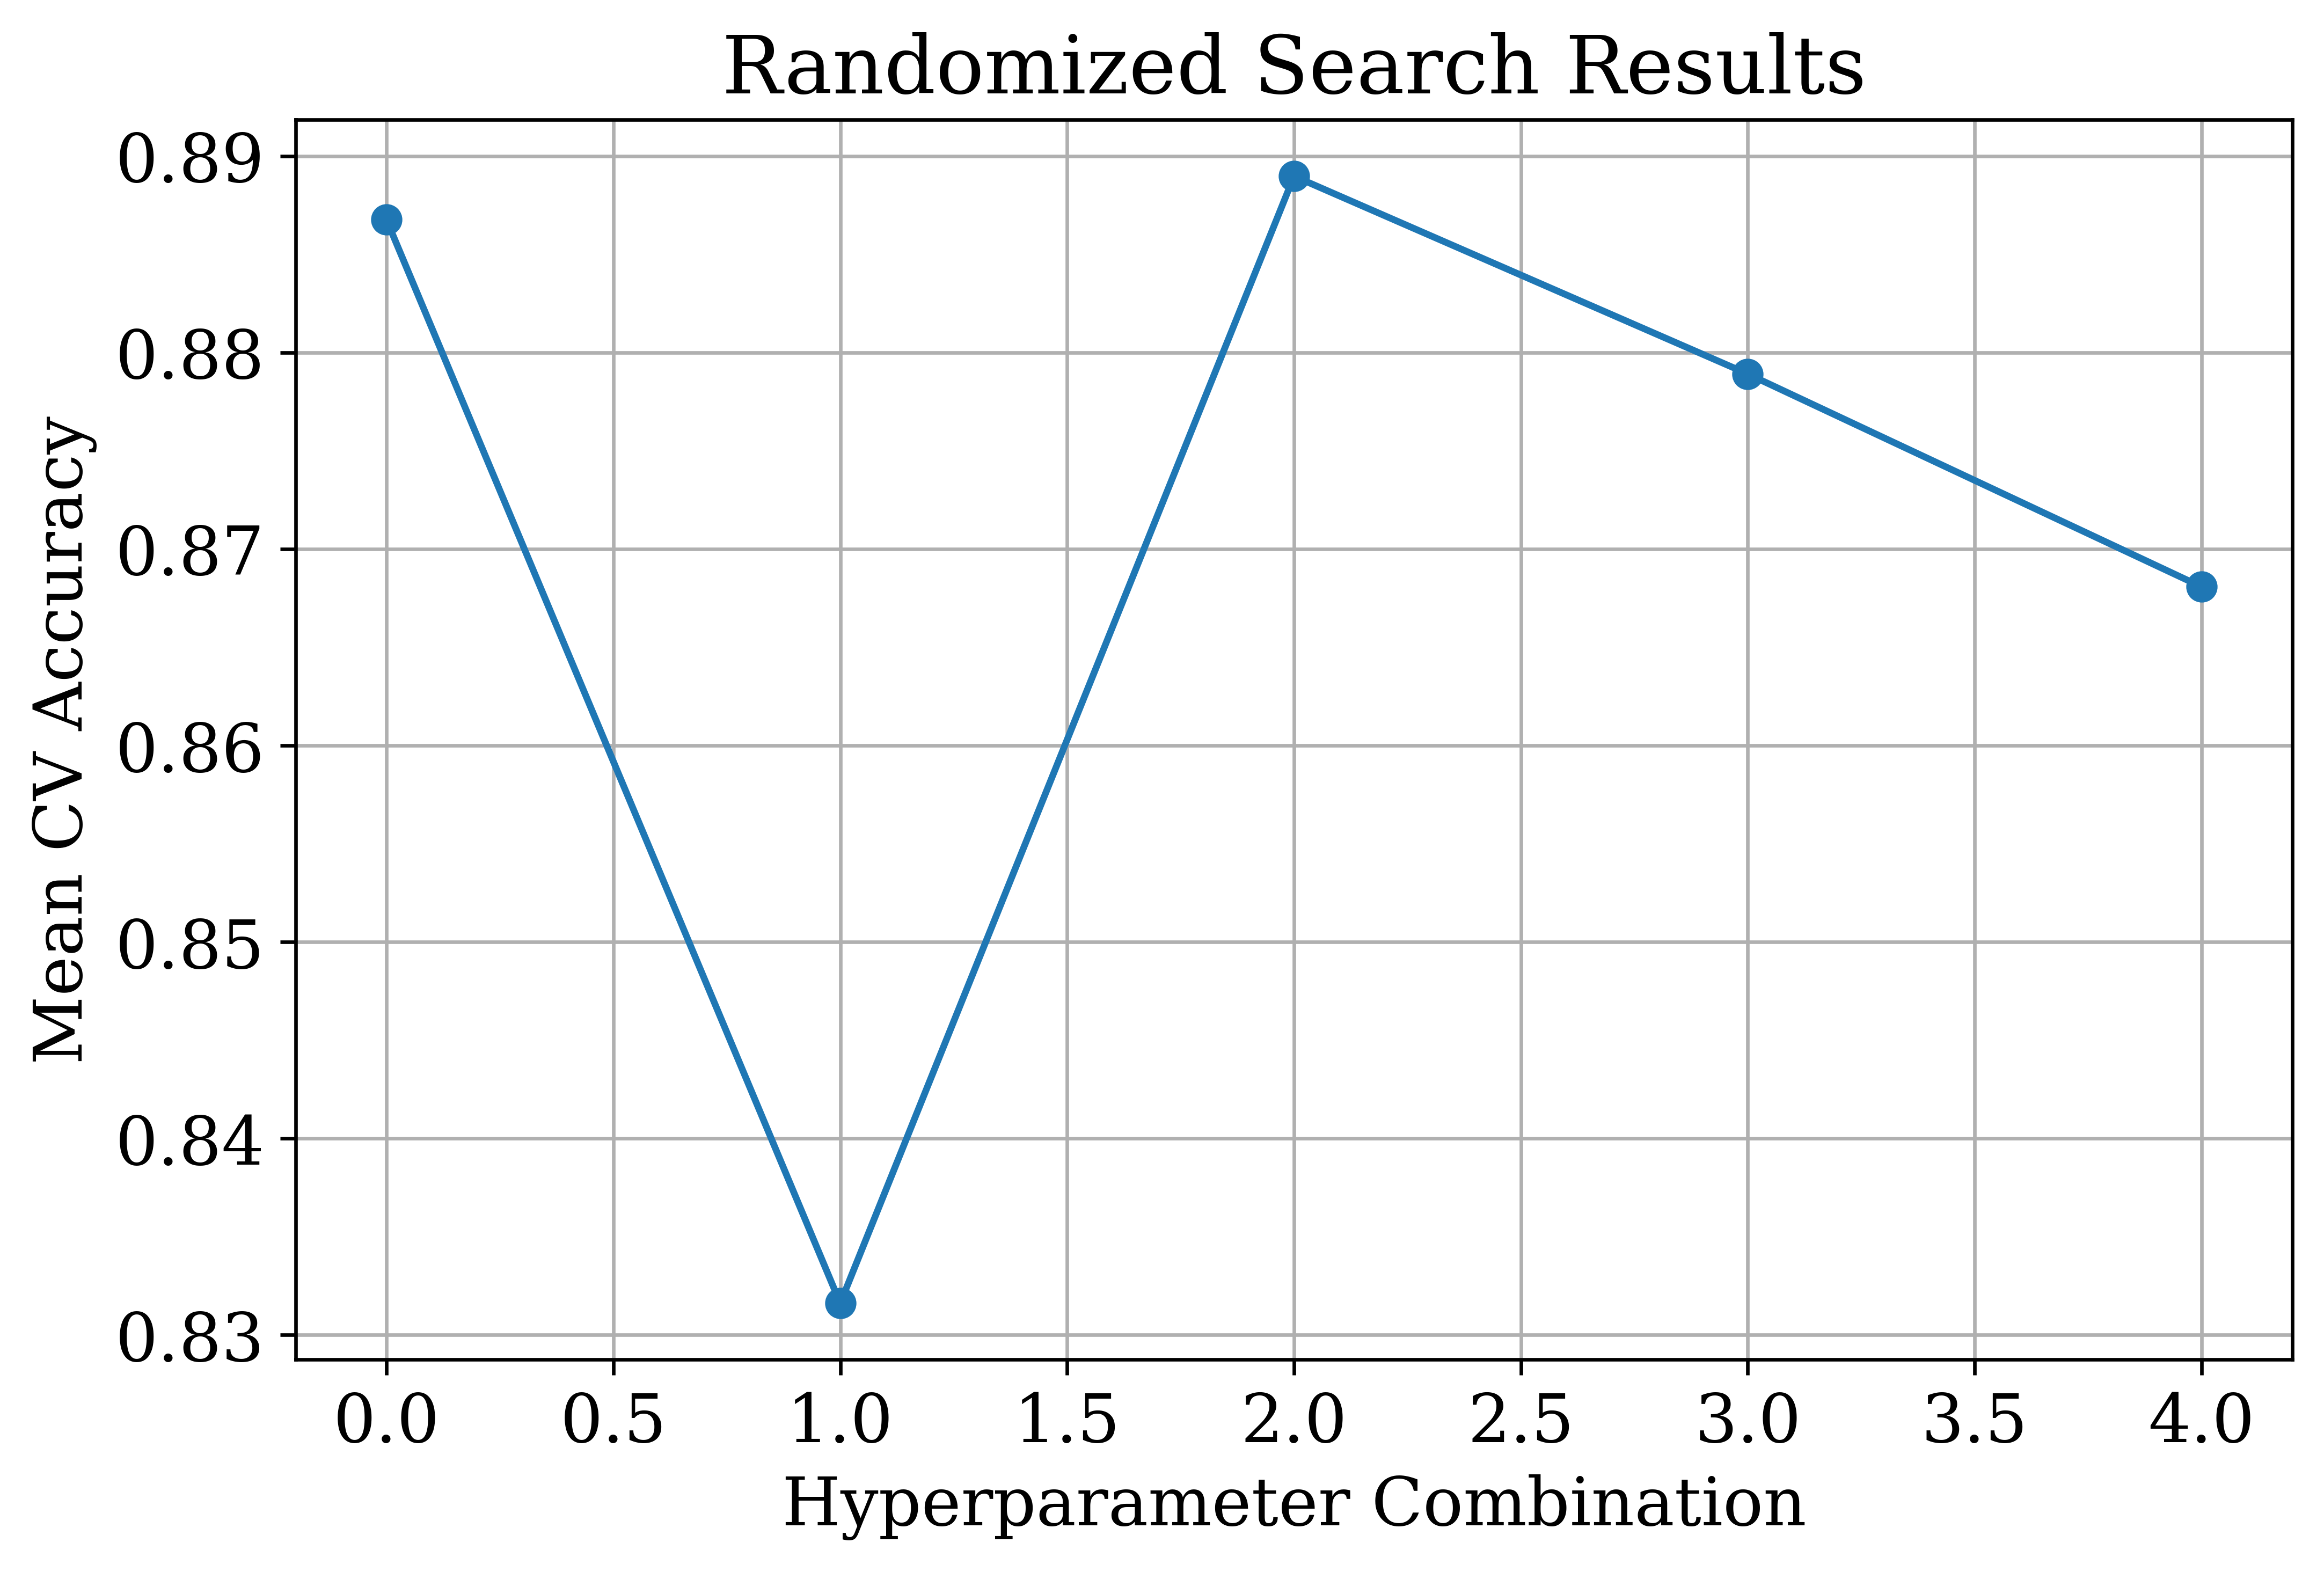

<Figure size 3840x2880 with 0 Axes>

In [ ]:
import pandas as pd

results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(results["mean_test_score"], marker='o')
plt.xlabel("Hyperparameter Combination")
plt.ylabel("Mean CV Accuracy")
plt.title("Randomized Search Results")
plt.grid(True)

plt.savefig(
    "Randomized_Search_Results.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

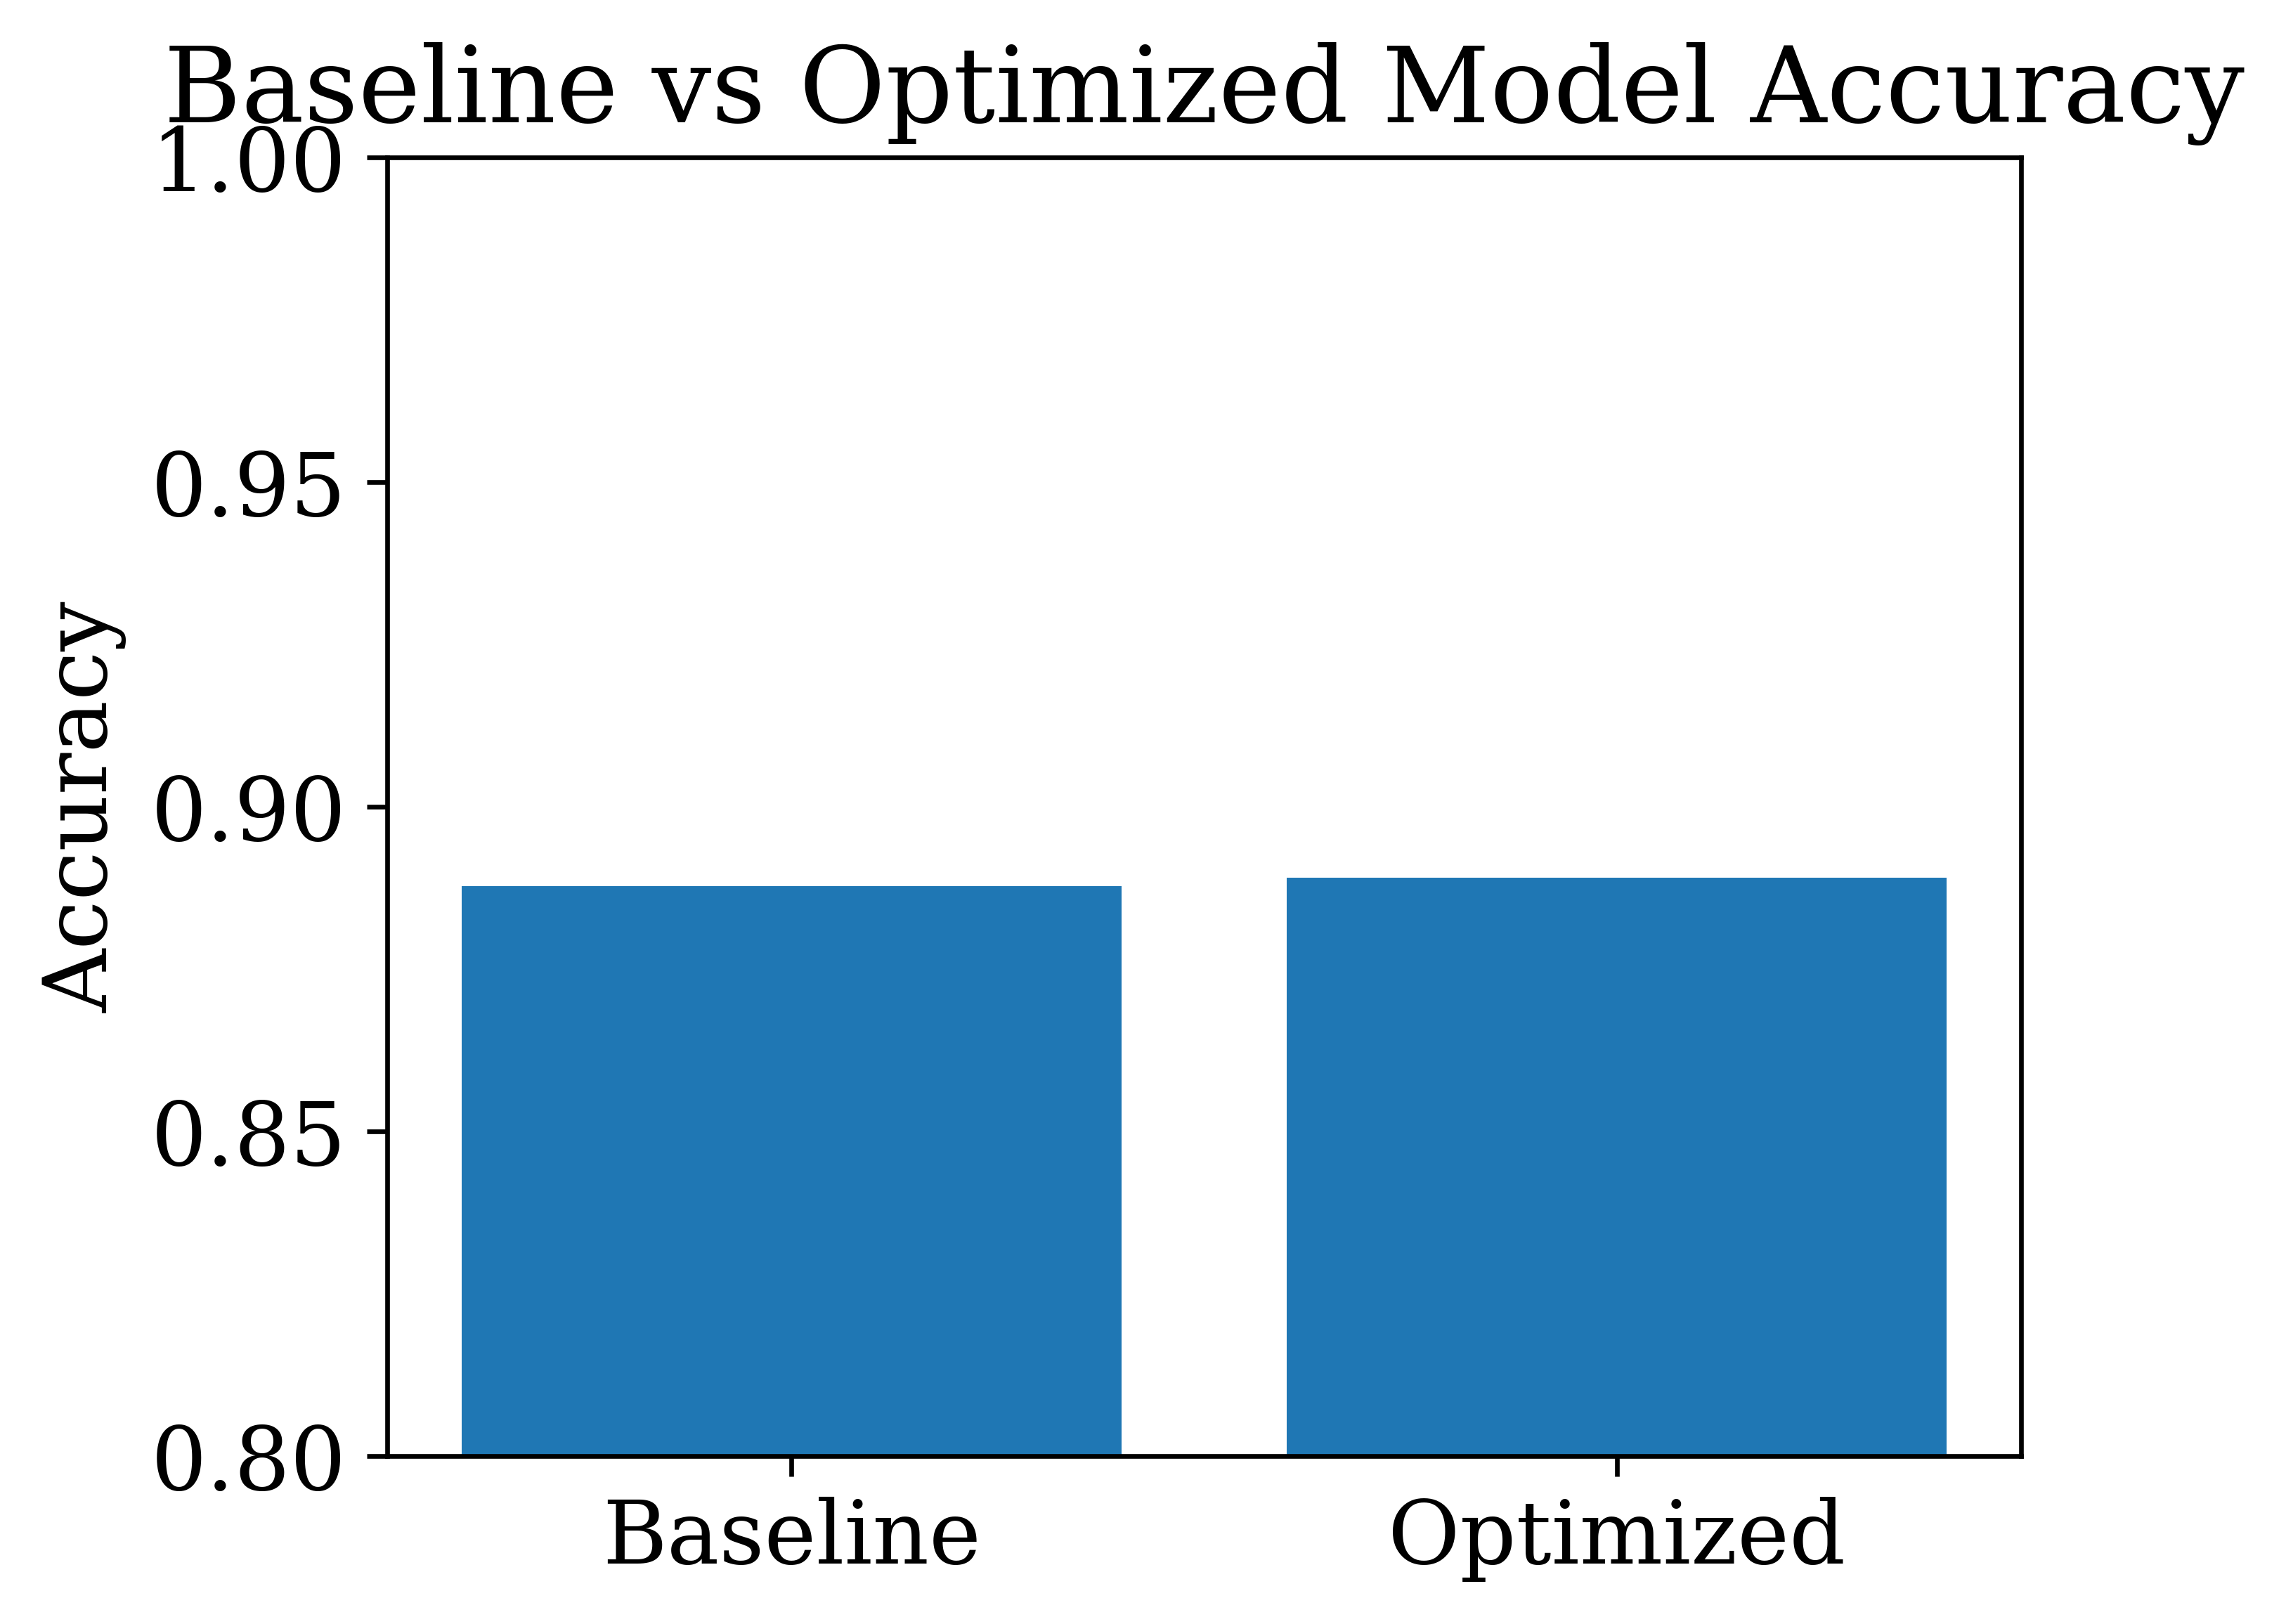

<Figure size 3840x2880 with 0 Axes>

In [ ]:
baseline_acc=0.8877000212669373
optimized_acc=0.8889833333333333

plt.figure(figsize=(5,4))
plt.bar(
    ['Baseline', 'Optimized'],
    [baseline_acc, optimized_acc]
)
plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model Accuracy")
plt.ylim(0.8,1.0)

plt.savefig(
    "Baseline_Vs_Optimized_Model_Accuracy.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()